In [13]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
# Load data
df = pd.read_excel('FG500_DataCollection_FY26_v3.xlsm',sheet_name='FG500_DataCollection_FY26', skiprows=2)

country_counts = df.groupby('Country').agg({
    'All CN': 'sum',
    'All SBTi ST': 'sum', 
    'All NZ': 'sum',
    'All RE': 'sum'
}).reset_index()

country_counts['total'] = country_counts[['All CN', 'All SBTi ST', 'All NZ', 'All RE']].sum(axis=1)

fig = px.scatter_geo(
    country_counts,
    locations='Country',
    locationmode='country names',
    size='total',
    color='total',
    hover_name='Country',
    hover_data=['All CN', 'All SBTi ST', 'All NZ', 'All RE'],
    projection='natural earth',
    color_continuous_scale=[(0, '#8B479B'), (0.33, '#00B4B2'), (0.66, '#4D58A6'), (1, '#008ACA')]
)

fig.show()
fig.write_html("climate_map.html")

C:\Users\AniyaBagheri\AppData\Local\Temp\ipykernel_14828\3808239731.py:16: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [14]:
import pandas as pd
import plotly.graph_objects as go

df = pd.read_excel('FG500_DataCollection_FY26_v3.xlsm', sheet_name='FG500_DataCollection_FY26', skiprows=2)

country_counts = df.groupby('Country').agg({
    'All CN': 'sum',
    'All SBTi ST': 'sum', 
    'All NZ': 'sum',
    'All RE': 'sum'
}).reset_index()

colors = {
    'All SBTi ST': '#008ACA',
    'All RE': '#4D58A6',
    'All NZ': '#00B4B2',
    'All CN': '#8B479B'
}

fig = go.Figure()

for target, color in colors.items():
    fig.add_trace(go.Scattergeo(
        locations=country_counts['Country'],
        locationmode='country names',
        marker=dict(size=country_counts[target]*2, color=color, line_width=0),
        name=target.replace('All ', ''),
        hovertemplate='%{location}<br>' + target + ': %{marker.size}<extra></extra>'
    ))

fig.update_geos(projection_type='natural earth')
fig.update_layout(showlegend=True)
fig.show()

In [16]:
pip install pycountry_convert


   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ----------------------- ---------------- 3.7/6.3 MB 21.4 MB/s eta 0:00:01
   ---------------------------------------  6.3/6.3 MB 18.0 MB/s eta 0:00:01
   ---------------------------------------- 6.3/6.3 MB 13.4 MB/s  0:00:00

   --- ------------------------------------  1/11 [pprintpp]
   --- ------------------------------------  1/11 [pprintpp]
   --- ------------------------------------  1/11 [pprintpp]
   --- ------------------------------------  1/11 [pprintpp]
   --- ------------------------------------  1/11 [pprintpp]
   ------- --------------------------------  2/11 [wheel]
   ------- --------------------------------  2/11 [wheel]
   ------- --------------------------------  2/11 [wheel]
   ------- --------------------------------  2/11 [wheel]
   ---------- -----------------------------  3/11 [pycountry]
   ---------- -----------------------------  3/11 [pycountry]
   ---------- ---------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [18]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

df = pd.read_excel('FG500_DataCollection_FY26_v3.xlsm', sheet_name='FG500_DataCollection_FY26', skiprows=2)

country_counts = df.groupby('Country').agg({
    'All CN': 'sum',
    'All SBTi ST': 'sum', 
    'All NZ': 'sum',
    'All RE': 'sum'
}).reset_index()

# Get country coordinates (you'll need a mapping dict or library)
import pycountry_convert as pc

def get_country_coords(country_name):
    # Approximate coordinates - replace with proper geocoding
    coords = {
        'United States': (37, -95),
        'China': (35, 105),
        'Japan': (36, 138),
        'Germany': (51, 10),
        'United Kingdom': (55, -3),
        # Add more as needed
    }
    return coords.get(country_name, (0, 0))

colors = {
    'All SBTi ST': '#008ACA',
    'All RE': '#4D58A6',
    'All NZ': '#00B4B2',
    'All CN': '#8B479B'
}

fig = go.Figure()

offsets = [(0, 0.1), (0.1, 0), (0, -0.1), (-0.1, 0)]

for i, (target, color) in enumerate(colors.items()):
    lats = []
    lons = []
    sizes = []
    countries = []
    
    for _, row in country_counts.iterrows():
        if row[target] > 0:
            lat, lon = get_country_coords(row['Country'])
            lats.append(lat + offsets[i][0])
            lons.append(lon + offsets[i][1])
            sizes.append(row[target] * 3)
            countries.append(row['Country'])
    
    fig.add_trace(go.Scattergeo(
        lat=lats,
        lon=lons,
        marker=dict(size=sizes, color=color, line_width=0, opacity=0.7),
        name=target.replace('All ', ''),
        text=countries,
        hovertemplate='%{text}<br>' + target + ': %{marker.size}<extra></extra>'
    ))

fig.update_geos(projection_type='natural earth')
fig.show()

In [19]:
import pandas as pd
import plotly.graph_objects as go

df = pd.read_excel('FG500_DataCollection_FY26_v3.xlsm', sheet_name='FG500_DataCollection_FY26', skiprows=2)

country_counts = df.groupby('Country').agg({
    'All CN': 'sum',
    'All SBTi ST': 'sum', 
    'All NZ': 'sum',
    'All RE': 'sum'
}).reset_index()

country_coords = {
    'United States': (37, -95),
    'China': (35, 105),
    'Japan': (36, 138),
    'Germany': (51, 10),
    'United Kingdom': (55, -3),
    'France': (46, 2),
    'India': (20, 77),
    'Italy': (42, 12),
    'Canada': (56, -106),
    'South Korea': (37, 127),
    'Russia': (61, 105),
    'Spain': (40, -4),
    'Australia': (-25, 133),
    'Brazil': (-14, -51),
    'Netherlands': (52, 5),
    'Switzerland': (47, 8),
    'Saudi Arabia': (24, 45),
    'Turkey': (39, 35),
    'Taiwan': (24, 121),
    'Poland': (52, 20),
    'Belgium': (50, 4),
    'Sweden': (60, 15),
    'Ireland': (53, -8),
    'Austria': (47, 14),
    'Norway': (60, 8),
    'United Arab Emirates': (24, 54),
    'Thailand': (15, 101),
    'Singapore': (1, 103),
    'Israel': (31, 35),
    'Hong Kong': (22, 114),
    'Denmark': (56, 9),
    'Malaysia': (4, 101),
    'South Africa': (-30, 25),
    'Colombia': (4, -72),
    'Finland': (64, 26),
    'Chile': (-30, -71),
    'Portugal': (39, -8),
    'Greece': (39, 22),
    'Czech Republic': (50, 15),
    'Romania': (46, 25),
    'New Zealand': (-41, 174),
    'Iraq': (33, 44),
    'Peru': (-10, -76),
    'Qatar': (25, 51),
    'Kazakhstan': (48, 68),
    'Hungary': (47, 20),
    'Kuwait': (29, 48),
    'Luxembourg': (50, 6),
    'Morocco': (32, -5),
}

colors = {
    'All SBTi ST': '#008ACA',
    'All RE': '#4D58A6',
    'All NZ': '#00B4B2',
    'All CN': '#8B479B'
}

offsets = [(0, 1), (1, 0), (0, -1), (-1, 0)]

fig = go.Figure()

for idx, (target, color) in enumerate(colors.items()):
    lats, lons, sizes, texts = [], [], [], []
    
    for _, row in country_counts.iterrows():
        if row[target] > 0 and row['Country'] in country_coords:
            lat, lon = country_coords[row['Country']]
            lats.append(lat + offsets[idx][0])
            lons.append(lon + offsets[idx][1])
            sizes.append(row[target] * 5)
            texts.append(f"{row['Country']}<br>{target}: {row[target]}")
    
    fig.add_trace(go.Scattergeo(
        lat=lats,
        lon=lons,
        marker=dict(size=sizes, color=color, opacity=0.6),
        name=target.replace('All ', ''),
        text=texts,
        hovertemplate='%{text}<extra></extra>'
    ))

fig.update_geos(projection_type='natural earth', showland=True, landcolor='lightgray')
fig.show()

In [ ]:

import pandas as pd
import plotly.graph_objects as go

df = pd.read_excel('FG500_DataCollection_FY26_v3.xlsm', sheet_name='FG500_DataCollection_FY26', skiprows=2)

country_counts = df.groupby('Country').agg({
    'All CN': 'sum',
    'All SBTi ST': 'sum', 
    'All NZ': 'sum',
    'All RE': 'sum'
}).reset_index()

country_coords = {
    'U.S.': (37, -95),
    'China': (35, 105),
    'Japan': (36, 138),
    'Germany': (51, 10),
    'Britain': (55, -3),
    'U.K.': (55, -3),
    'France': (46, 2),
    'India': (20, 77),
    'Italy': (42, 12),
    'Canada': (56, -106),
    'South Korea': (37, 127),
    'Russia': (61, 105),
    'Spain': (40, -4),
    'Australia': (-25, 133),
    'Brazil': (-14, -51),
    'Netherlands': (52, 5),
    'Switzerland': (47, 8),
    'Saudi Arabia': (24, 45),
    'Turkey': (39, 35),
    'Taiwan': (24, 121),
    'Poland': (52, 20),
    'Belgium': (50, 4),
    'Sweden': (60, 15),
    'Ireland': (53, -8),
    'Austria': (47, 14),
    'Norway': (60, 8),
    'UAE': (24, 54),
    'Thailand': (15, 101),
    'Singapore': (1, 103),
    'Israel': (31, 35),
    'Hong Kong': (22, 114),
    'Denmark': (56, 9),
    'Malaysia': (4, 101),
    'South Africa': (-30, 25),
    'Colombia': (4, -72),
    'Finland': (64, 26),
    'Chile': (-30, -71),
    'Portugal': (39, -8),
    'Greece': (39, 22),
    'Czech Republic': (50, 15),
    'Romania': (46, 25),
    'New Zealand': (-41, 174),
    'Iraq': (33, 44),
    'Peru': (-10, -76),
    'Qatar': (25, 51),
    'Kazakhstan': (48, 68),
    'Hungary': (47, 20),
    'Kuwait': (29, 48),
    'Luxembourg': (50, 6),
    'Morocco': (32, -5),
    'Mexico': (23, -102),
    'Indonesia': (-2, 118),
}

colors = {'All SBTi ST': '#008ACA', 'All RE': '#ffff00', 'All NZ': '#00B4B2', 'All CN': '#8B479B'}
offsets = [(0, 1), (1, 0), (0, -1), (-1, 0)]

fig = go.Figure()

for idx, (target, color) in enumerate(colors.items()):
    lats, lons, sizes, texts = [], [], [], []
    
    for _, row in country_counts.iterrows():
        if row[target] > 0 and row['Country'] in country_coords:
            lat, lon = country_coords[row['Country']]
            lats.append(lat + offsets[idx][0])
            lons.append(lon + offsets[idx][1])
            sizes.append(row[target] * 5)
            texts.append(f"{row['Country']}<br>{target}: {row[target]}")
    
    fig.add_trace(go.Scattergeo(
        lat=lats, lon=lons,
        marker=dict(size=sizes, color=color, opacity=0.7),
        name=target.replace('All ', ''),
        text=texts,
        hovertemplate='%{text}<extra></extra>'
    ))

fig.update_geos(
    projection_type='natural earth',
    showland=True,
    landcolor='#2a2a2a',
    oceancolor="#050505",
    showcountries=True,
    countrycolor='#4a4a4a'
)

fig.update_layout(
    paper_bgcolor='#6a6a6a',
    plot_bgcolor='#1a1a1a',
    font=dict(color='white')
)

fig.show()
fig.write_html("geo_regional_targets.html")

In [2]:
import pandas as pd
import plotly.graph_objects as go

# Load data
df = pd.read_excel(
    r'C:\Users\AniyaBagheri\GF500_research_perliminary_data_analysis\FG500_DataCollection_FY26_v4.cleaned.xlsm.xlsx',
    sheet_name='FG500_DataCollection_FY26',
    skiprows=2
)

# Strip whitespace from column names to avoid hidden trailing spaces
df.columns = df.columns.str.strip()

# Columns you want to use — note 'ALL CN' is uppercase
required_columns = ['Country', 'ALL CN', 'All SBTi ST', 'All NZ', 'All RE']

# Check that all required columns exist in the dataframe
for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found. Available columns:\n{df.columns.tolist()}")

# Group by country and sum the target counts
country_counts = df.groupby('Country')[required_columns[1:]].sum().reset_index()

# Country coordinates for plotting
country_coords = {
    'U.S.': (37, -95), 'China': (35, 105), 'Japan': (36, 138),
    'Germany': (51, 10), 'Britain': (55, -3), 'U.K.': (55, -3),
    'France': (46, 2), 'India': (20, 77), 'Italy': (42, 12),
    'Canada': (56, -106), 'South Korea': (37, 127), 'Russia': (61, 105),
    'Spain': (40, -4), 'Australia': (-25, 133), 'Brazil': (-14, -51),
    'Netherlands': (52, 5), 'Switzerland': (47, 8), 'Saudi Arabia': (24, 45),
    'Turkey': (39, 35), 'Taiwan': (24, 121), 'Poland': (52, 20),
    'Belgium': (50, 4), 'Sweden': (60, 15), 'Ireland': (53, -8),
    'Austria': (47, 14), 'Norway': (60, 8), 'UAE': (24, 54),
    'Thailand': (15, 101), 'Singapore': (1, 103), 'Denmark': (56, 9),
    'Malaysia': (4, 101), 'Colombia': (4, -72), 'Finland': (64, 26),
    'Portugal': (39, -8), 'Qatar': (25, 51), 'Luxembourg': (50, 6),
    'Mexico': (23, -102), 'Indonesia': (-2, 118),
}

# Colors for each target type
colors = {'All SBTi ST': '#008ACA', 'All RE': '#4D58A6', 'All NZ': '#00B4B2', 'ALL CN': '#8B479B'}

# Marker offsets to prevent overlap
offsets = [(0, 1), (1, 0), (0, -1), (-1, 0)]

fig = go.Figure()

for idx, (target, color) in enumerate(colors.items()):
    lats, lons, sizes, texts = [], [], [], []
    
    for _, row in country_counts.iterrows():
        if row[target] > 0 and row['Country'] in country_coords:
            lat, lon = country_coords[row['Country']]
            # Add small offset so markers don’t fully overlap
            lats.append(lat + offsets[idx][0])
            lons.append(lon + offsets[idx][1])
            sizes.append(min(row[target] * 3, 50))  # size scaled, max 50
            texts.append(f"{row['Country']}<br>{target}: {row[target]}")
    
    fig.add_trace(go.Scattergeo(
        lat=lats, lon=lons,
        marker=dict(size=sizes, color=color, opacity=0.7),
        name=target.replace('All ', '').replace('ALL ', ''),
        text=texts,
        hovertemplate='%{text}<extra></extra>'
    ))

fig.update_geos(
    projection_type='natural earth',
    showland=True,
    landcolor='#2a2a2a',
    oceancolor='#1a1a1a',
    showcountries=True,
    countrycolor='#4a4a4a'
)

fig.update_layout(
    paper_bgcolor='#1a1a1a',
    plot_bgcolor='#1a1a1a',
    font=dict(color='white'),
    title_text="Regional Targets by Country"
)

fig.write_html('geo_regional_targets.html', include_plotlyjs='cdn')
fig.show()



In [3]:
import pandas as pd
import plotly.graph_objects as go

# Load data
df = pd.read_excel(
    r'C:\Users\AniyaBagheri\GF500_research_perliminary_data_analysis\FG500_DataCollection_FY26_v4.cleaned.xlsm.xlsx',
    sheet_name='FG500_DataCollection_FY26', skiprows=2
)

# Normalize country names: map 'Britain' to 'U.K.'
df['Country'] = df['Country'].replace({'Britain': 'U.K.'})

# Optional: Strip whitespace from column names if needed
df.columns = df.columns.str.strip()

# Columns to aggregate
required_columns = ['ALL CN', 'All SBTi ST', 'All NZ', 'All RE']

# Check required columns exist
for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found. Available columns:\n{df.columns.tolist()}")

# Group by country and sum target counts
country_counts = df.groupby('Country')[required_columns].sum().reset_index()

# Updated country coordinates with only 'U.K.', no 'Britain'
country_coords = {
    'U.S.': (37, -95), 'China': (35, 105), 'Japan': (36, 138),
    'Germany': (51, 10), 'U.K.': (55, -3),  # Only U.K. here
    'France': (46, 2), 'India': (20, 77), 'Italy': (42, 12),
    'Canada': (56, -106), 'South Korea': (37, 127), 'Russia': (61, 105),
    'Spain': (40, -4), 'Australia': (-25, 133), 'Brazil': (-14, -51),
    'Netherlands': (52, 5), 'Switzerland': (47, 8), 'Saudi Arabia': (24, 45),
    'Turkey': (39, 35), 'Taiwan': (24, 121), 'Poland': (52, 20),
    'Belgium': (50, 4), 'Sweden': (60, 15), 'Ireland': (53, -8),
    'Austria': (47, 14), 'Norway': (60, 8), 'UAE': (24, 54),
    'Thailand': (15, 101), 'Singapore': (1, 103), 'Denmark': (56, 9),
    'Malaysia': (4, 101), 'Colombia': (4, -72), 'Finland': (64, 26),
    'Portugal': (39, -8), 'Qatar': (25, 51), 'Luxembourg': (50, 6),
    'Mexico': (23, -102), 'Indonesia': (-2, 118),
}

colors = {'All SBTi ST': '#008ACA', 'All RE': '#4D58A6', 'All NZ': '#00B4B2', 'ALL CN': '#8B479B'}
offsets = [(0, 1), (1, 0), (0, -1), (-1, 0)]

fig = go.Figure()

for idx, (target, color) in enumerate(colors.items()):
    lats, lons, sizes, texts = [], [], [], []

    for _, row in country_counts.iterrows():
        if row[target] > 0 and row['Country'] in country_coords:
            lat, lon = country_coords[row['Country']]
            lats.append(lat + offsets[idx][0])
            lons.append(lon + offsets[idx][1])
            sizes.append(min(row[target] * 3, 50))
            texts.append(f"{row['Country']}<br>{target}: {row[target]}")

    fig.add_trace(go.Scattergeo(
        lat=lats, lon=lons,
        marker=dict(size=sizes, color=color, opacity=0.7),
        name=target.replace('All ', ''),
        text=texts,
        hovertemplate='%{text}<extra></extra>'
    ))

fig.update_geos(
    projection_type='natural earth',
    showland=True,
    landcolor='#2a2a2a',
    oceancolor='#1a1a1a',
    showcountries=True,
    countrycolor='#4a4a4a'
)

fig.update_layout(
    paper_bgcolor='#1a1a1a',
    plot_bgcolor='#1a1a1a',
    font=dict(color='white')
)

fig.write_html('geo_regional_targets.html', include_plotlyjs='cdn')
fig.show()

In [4]:
import pandas as pd
import plotly.express as px

df = pd.read_excel(
    r'C:\Users\AniyaBagheri\GF500_research_perliminary_data_analysis\FG500_DataCollection_FY26_v4.cleaned.xlsm.xlsx',
    sheet_name='FG500_DataCollection_FY26', skiprows=2
)

df['Country'] = df['Country'].replace({'Britain': 'U.K.'})
df.columns = df.columns.str.strip()

required_columns = ['ALL CN', 'All SBTi ST', 'All NZ', 'All RE']
country_data = df.groupby('Country')[required_columns].sum().reset_index()

country_data['Total'] = country_data[required_columns].sum(axis=1)
for col in required_columns:
    country_data[f'{col}_pct'] = (country_data[col] / country_data['Total'] * 100).round(1)

country_data['hover_text'] = country_data.apply(
    lambda row: f"<b>{row['Country']}</b><br>Total Targets: {int(row['Total'])}<br>" +
                f"CN: {row['ALL CN_pct']}%<br>" +
                f"SBTi: {row['All SBTi ST_pct']}%<br>" +
                f"NZ: {row['All NZ_pct']}%<br>" +
                f"RE: {row['All RE_pct']}%",
    axis=1
)

fig = px.choropleth(
    country_data,
    locations='Country',
    locationmode='country names',
    color='Total',
    hover_name='Country',
    hover_data={'Country': False, 'Total': False, 'hover_text': True},
    color_continuous_scale='Blues'
)

fig.update_traces(hovertemplate='%{customdata[0]}')

fig.update_geos(
    projection_type='natural earth',
    showland=True,
    landcolor='#2a2a2a',
    oceancolor='#1a1a1a',
    showcountries=True,
    countrycolor='#4a4a4a'
)

fig.update_layout(
    paper_bgcolor='#1a1a1a',
    plot_bgcolor='#1a1a1a',
    font=dict(color='white'),
    coloraxis_colorbar=dict(title="Total Targets")
)

fig.write_html('country_target_breakdown.html', include_plotlyjs='cdn')
fig.show()

C:\Users\AniyaBagheri\AppData\Local\Temp\ipykernel_31152\1924430548.py:28: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [6]:
pip install kaleido


   ---------------------------------------- 0/6 [simplejson]
   ---------------------------------------- 0/6 [simplejson]
   ---------------------------------------- 0/6 [simplejson]
   ---------------------------------------- 0/6 [simplejson]
   ------------- -------------------------- 2/6 [logistro]
   -------------------------- ------------- 4/6 [choreographer]
   -------------------------- ------------- 4/6 [choreographer]
   -------------------------- ------------- 4/6 [choreographer]
   -------------------------- ------------- 4/6 [choreographer]
   -------------------------- ------------- 4/6 [choreographer]
   --------------------------------- ------ 5/6 [kaleido]
   --------------------------------- ------ 5/6 [kaleido]
   --------------------------------- ------ 5/6 [kaleido]
   --------------------------------- ------ 5/6 [kaleido]
   ---------------------------------------- 6/6 [kaleido]

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import pandas as pd
import plotly.graph_objects as go

df = pd.read_excel(
    r'C:\Users\AniyaBagheri\GF500_research_perliminary_data_analysis\FG500_DataCollection_FY26_v4.cleaned.xlsm.xlsx',
    sheet_name='FG500_DataCollection_FY26', skiprows=2
)

df['Country'] = df['Country'].replace({'Britain': 'U.K.'})
df.columns = df.columns.str.strip()

region_map = {
    'U.S.': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    'China': 'Asia', 'Japan': 'Asia', 'India': 'Asia', 'South Korea': 'Asia', 'Taiwan': 'Asia',
    'Thailand': 'Asia', 'Singapore': 'Asia', 'Malaysia': 'Asia', 'Indonesia': 'Asia',
    'Germany': 'Europe', 'U.K.': 'Europe', 'France': 'Europe', 'Italy': 'Europe', 
    'Russia': 'Europe', 'Spain': 'Europe', 'Netherlands': 'Europe', 'Switzerland': 'Europe',
    'Turkey': 'Europe', 'Poland': 'Europe', 'Belgium': 'Europe', 'Sweden': 'Europe',
    'Ireland': 'Europe', 'Austria': 'Europe', 'Norway': 'Europe', 'Denmark': 'Europe',
    'Finland': 'Europe', 'Portugal': 'Europe', 'Luxembourg': 'Europe',
    'Saudi Arabia': 'Middle East', 'UAE': 'Middle East', 'Qatar': 'Middle East',
    'Brazil': 'Latin America', 'Colombia': 'Latin America',
    'Australia': 'Oceania'
}

df['Region'] = df['Country'].map(region_map)
required_columns = ['ALL CN', 'All SBTi ST', 'All NZ', 'All RE']

region_data = df.groupby('Region')[required_columns].sum().reset_index()
region_data['Total'] = region_data[required_columns].sum(axis=1)

for col in required_columns:
    region_data[f'{col}_pct'] = (region_data[col] / region_data['Total'] * 100).round(1)

region_coords = {
    'North America': (45, -100),
    'Europe': (50, 10),
    'Asia': (30, 100),
    'Middle East': (25, 45),
    'Latin America': (-10, -60),
    'Oceania': (-25, 135)
}

colors = {'All SBTi ST': '#008ACA', 'All RE': '#4D58A6', 'All NZ': '#00B4B2', 'ALL CN': '#8B479B'}

fig = go.Figure()

for target, color in colors.items():
    lats, lons, sizes, texts = [], [], [], []
    for _, row in region_data.iterrows():
        if row['Region'] in region_coords:
            lat, lon = region_coords[row['Region']]
            pct = row[f'{target}_pct']
            lats.append(lat)
            lons.append(lon)
            sizes.append(pct * 2)
            texts.append(f"{row['Region']}<br>{target.replace('All ', '').replace(' ST', '')}: {pct}%")
    
    fig.add_trace(go.Scattergeo(
        lat=lats, lon=lons,
        marker=dict(size=sizes, color=color, opacity=0.7),
        name=target.replace('All ', '').replace(' ST', ''),
        text=texts,
        hovertemplate='%{text}<extra></extra>'
    ))

fig.update_geos(
    projection_type='natural earth',
    showland=True,
    landcolor='#e5e5e5',
    oceancolor='white',
    showcountries=True,
    countrycolor='#cccccc'
)

fig.update_layout(
    width=1600,
    height=900,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(color='black', size=14),
    showlegend=True,
    legend=dict(x=0.02, y=0.98)
)

fig.write_image('regional_targets_map.png', scale=2)
fig.show()

In [10]:
pip install --upgrade kaleido

Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install --upgrade cartopy

  Using cached cartopy-0.25.0.tar.gz (10.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached shapely-2.1.2-cp314-cp314-win_amd64.whl.metadata (7.1 kB)
  Using cached pyshp-3.0.3-py3-none-any.whl.metadata (65 kB)
  Using cached pyproj-3.7.2-cp314-cp314-win_amd64.whl.metadata (31 kB)
Using cached pyproj-3.7.2-cp314-cp314-win_amd64.whl (6.4 MB)
Using cached pyshp-3.0.3-py3-none-any.whl (58 kB)
Using cached shapely-2.1.2-cp314-cp314-win_amd64.whl (1.8 MB)
Failed to build cartopy
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for cartopy (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [1167 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-314\cartopy
      copying lib\cartopy\crs.py -> build\lib.win-amd64-cpython-314\cartopy
      copying lib\cartopy\geodesic.py -> build\lib.win-amd64-cpython-314\cartopy
      copying lib\cartopy\img_transform.py -> build\lib.win-amd64-cpython-314\cartopy
      copying lib\cartopy\util.py -> build\lib.win-amd64-cpython-314\cartopy
      copying lib\cartopy\vector_transform.py -> build\lib.win-amd64-cpython-314\cartopy
      copying lib\cartopy\_epsg.py -> build\lib.win-amd64-cpython-314\cartopy
      copying lib\cartopy\_version.py -> build\lib.win-amd64-cpython-314\cartopy
      copying lib\cartopy\__init__.py -> build\lib.win-amd64-cpython-314\cartopy
      creating build\lib.win-amd64-cpython-314\cartopy\feature
   

In [2]:
pip install geopandas matplotlib descartes


  Using cached pyproj-3.7.2-cp314-cp314-win_amd64.whl.metadata (31 kB)
  Using cached shapely-2.1.2-cp314-cp314-win_amd64.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/23.6 MB ? eta -:--:--
   ----- ---------------------------------- 3.1/23.6 MB 16.6 MB/s eta 0:00:02
   ------------ --------------------------- 7.6/23.6 MB 19.8 MB/s eta 0:00:01
   ------------------- -------------------- 11.3/23.6 MB 19.1 MB/s eta 0:00:01
   -------------------------- ------------- 15.7/23.6 MB 19.5 MB/s eta 0:00:01
   --------------------------------- ------ 19.7/23.6 MB 19.6 MB/s eta 0:00:01
   ---------------------------------------  23.3/23.6 MB 19.6 MB/s eta 0:00:01
   ---------------------------------------  23.3/23.6 MB 19.6 MB/s eta 0:00:01
   ---------------------------------------- 23.6/23.6 MB 15.3 MB/s  0:00:01
Using cached pyproj-3.7.2-cp314-cp314-win_amd64.whl (6.4 MB)
Using cached shapely-2.1.2-cp314-cp314-win_amd64.whl (1.8 MB)

   --------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [8]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# --- Load data ---
df = pd.read_excel(
    r'C:\Users\AniyaBagheri\GF500_research_perliminary_data_analysis\FG500_DataCollection_FY26_v4.cleaned.xlsm.xlsx',
    sheet_name='FG500_DataCollection_FY26',
    skiprows=2
)

df['Country'] = df['Country'].replace({'Britain': 'U.K.'})
df.columns = df.columns.str.strip()

# --- Ensure you already have a Region column ---
# df['Region'] = ...  # You mentioned you already have this

required_columns = ['ALL CN', 'All SBTi ST', 'All NZ', 'All RE']

# --- Aggregate data by region ---
region_data = df.groupby('Region')[required_columns].sum().reset_index()
region_data['Total'] = region_data[required_columns].sum(axis=1)
for col in required_columns:
    region_data[f'{col}_pct'] = (region_data[col] / region_data['Total'] * 100).round(1)

# --- Load world shapefile manually ---
world = gpd.read_file(r"C:\Users\AniyaBagheri\GF500_research_perliminary_data_analysis\ne_110m_admin_0_countries.shp")

# --- Merge country shapefile with your data ---
# Ensure 'name' in shapefile matches 'Country' in your Excel
world = world.merge(df[['Country', 'Region']].drop_duplicates(), left_on='name', right_on='Country', how='left')

# --- Plotting setup ---
targets = ['All SBTi ST', 'All RE', 'All NZ', 'ALL CN']
colors = ['Blues', 'Purples', 'Greens', 'Oranges']

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

for ax, target, cmap in zip(axes, targets, colors):
    # Map region percentages to countries
    pct_map = region_data.set_index('Region')[f'{target}_pct'].to_dict()
    world['color_pct'] = world['Region'].map(pct_map)
    
    world.boundary.plot(ax=ax, linewidth=0.8, color='black')
    world.plot(column='color_pct', ax=ax, cmap=cmap, legend=True,
               legend_kwds={'label': f"% of {target.replace('All ', '').replace(' ST','')} Targets",
                            'orientation': "horizontal"})
    
    ax.set_title(f"{target.replace('All ', '').replace(' ST','')} by Region", fontsize=16)
    ax.axis('off')

plt.tight_layout()
plt.savefig("regional_targets_map.png", dpi=300)
plt.show()



KeyError: 'name'

In [9]:
import geopandas as gpd

world = gpd.read_file(r"C:\Users\AniyaBagheri\GF500_research_perliminary_data_analysis\ne_110m_admin_0_countries.shp")


print(world.columns)
print(world[['NAME', 'ADMIN']].head())  # adjust column names if needed


Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='object', length=169)
                       NAME                        ADMIN
0                      Fiji                         Fiji
1                  Tanzania  United Republic of Tanzania
2                 W. Sahara               Western Sahara
3                    Canada                       Canada
4  United States of America     United States of America


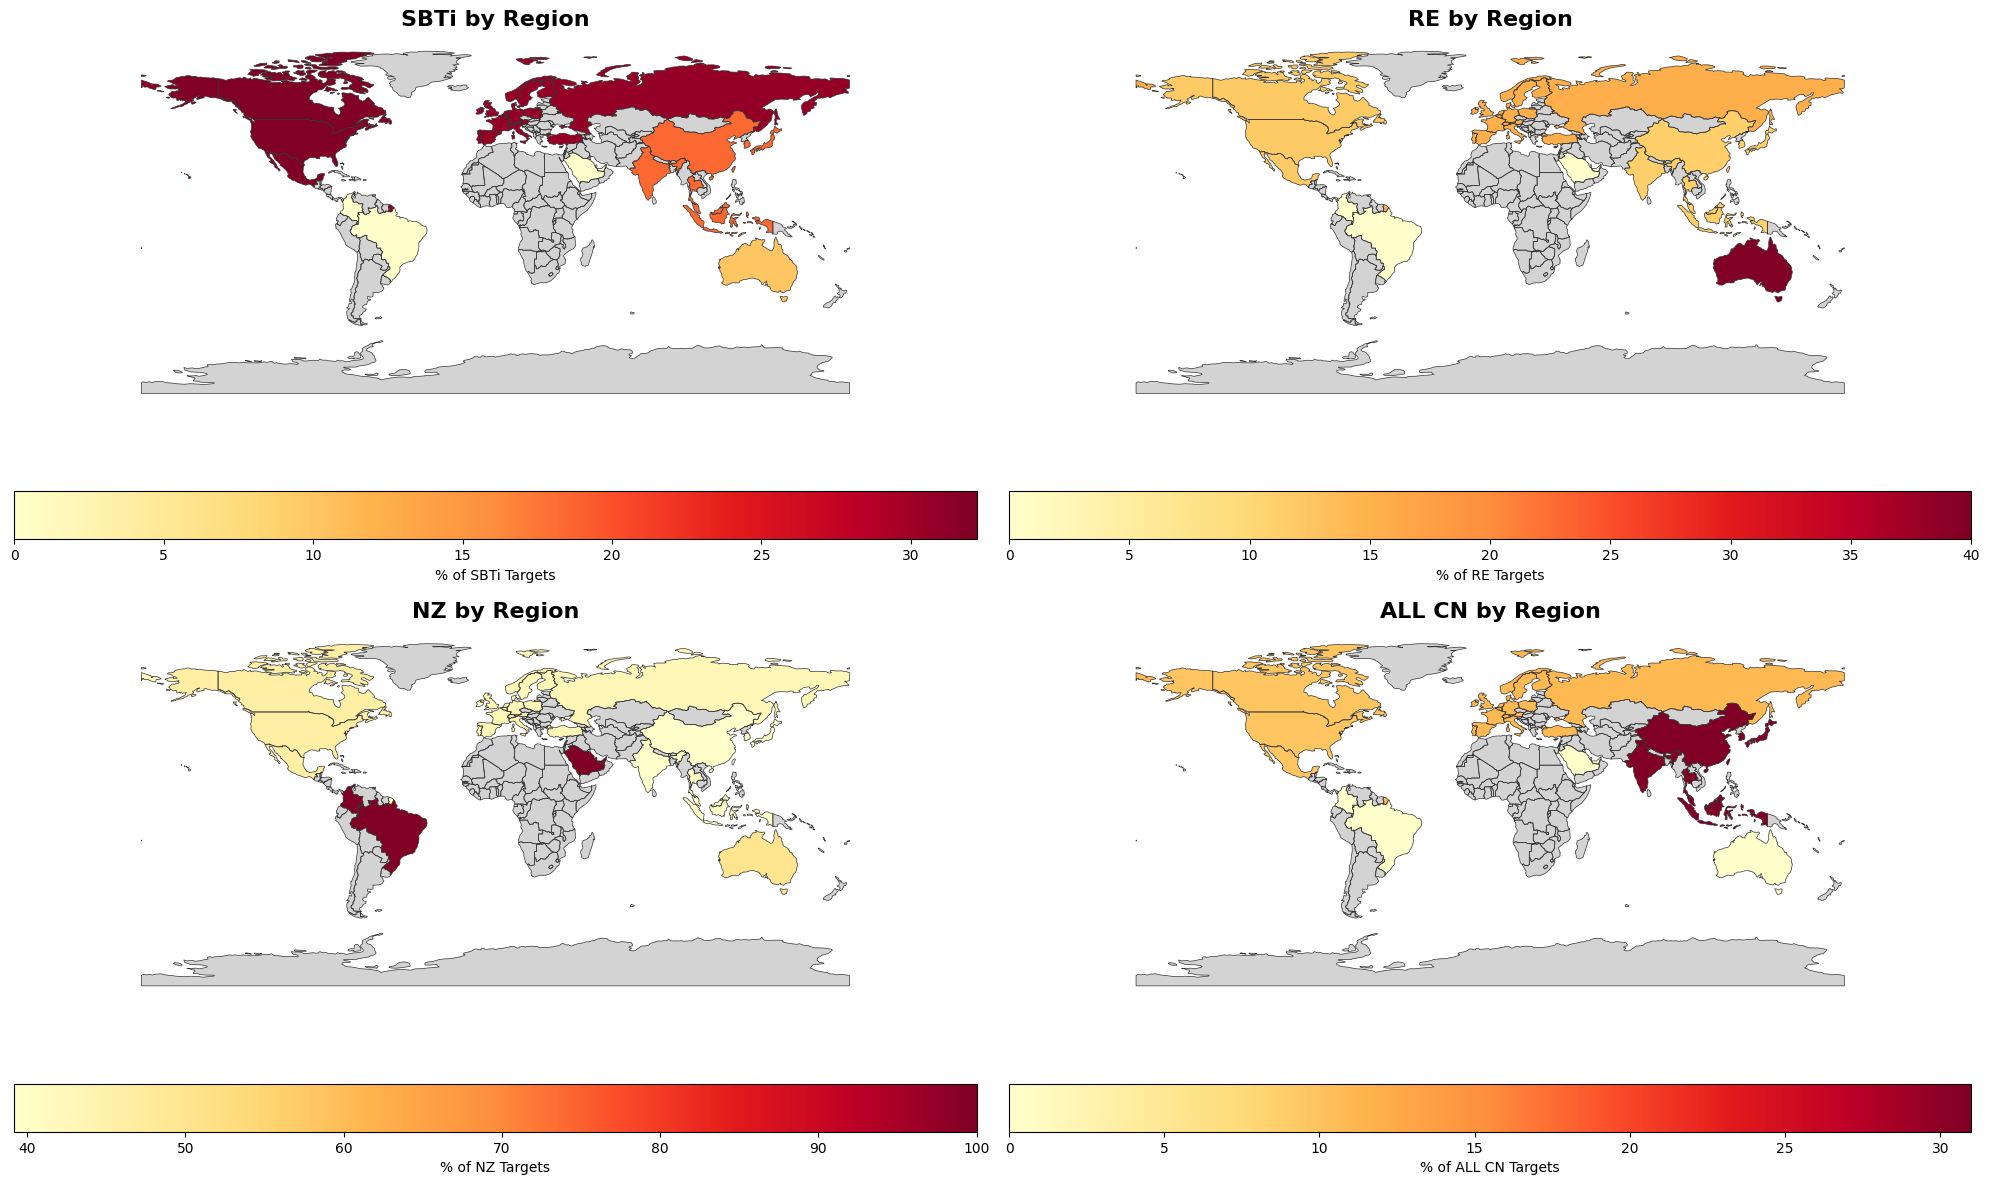

In [10]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# --- Load data ---
df = pd.read_excel(
    r'C:\Users\AniyaBagheri\GF500_research_perliminary_data_analysis\FG500_DataCollection_FY26_v4.cleaned.xlsm.xlsx',
    sheet_name='FG500_DataCollection_FY26',
    skiprows=2
)

df['Country'] = df['Country'].replace({'Britain': 'U.K.'})
df.columns = df.columns.str.strip()

# --- Region mapping ---
region_map = {
    'U.S.': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    'China': 'Asia', 'Japan': 'Asia', 'India': 'Asia', 'South Korea': 'Asia', 'Taiwan': 'Asia',
    'Thailand': 'Asia', 'Singapore': 'Asia', 'Malaysia': 'Asia', 'Indonesia': 'Asia',
    'Germany': 'Europe', 'U.K.': 'Europe', 'France': 'Europe', 'Italy': 'Europe', 
    'Russia': 'Europe', 'Spain': 'Europe', 'Netherlands': 'Europe', 'Switzerland': 'Europe',
    'Turkey': 'Europe', 'Poland': 'Europe', 'Belgium': 'Europe', 'Sweden': 'Europe',
    'Ireland': 'Europe', 'Austria': 'Europe', 'Norway': 'Europe', 'Denmark': 'Europe',
    'Finland': 'Europe', 'Portugal': 'Europe', 'Luxembourg': 'Europe',
    'Saudi Arabia': 'Middle East', 'UAE': 'Middle East', 'Qatar': 'Middle East',
    'Brazil': 'Latin America', 'Colombia': 'Latin America',
    'Australia': 'Oceania'
}

df['Region'] = df['Country'].map(region_map)

required_columns = ['ALL CN', 'All SBTi ST', 'All NZ', 'All RE']

# --- Aggregate data by region ---
region_data = df.groupby('Region')[required_columns].sum().reset_index()
region_data['Total'] = region_data[required_columns].sum(axis=1)
for col in required_columns:
    region_data[f'{col}_pct'] = (region_data[col] / region_data['Total'] * 100).round(1)

# --- Load world shapefile ---
world = gpd.read_file(r"C:\Users\AniyaBagheri\GF500_research_perliminary_data_analysis\ne_110m_admin_0_countries.shp")

# --- Create mapping from shapefile country names to your regions ---
shapefile_to_region = {
    'United States of America': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    'China': 'Asia', 'Japan': 'Asia', 'India': 'Asia', 'South Korea': 'Asia', 'Taiwan': 'Asia',
    'Thailand': 'Asia', 'Singapore': 'Asia', 'Malaysia': 'Asia', 'Indonesia': 'Asia',
    'Germany': 'Europe', 'United Kingdom': 'Europe', 'France': 'Europe', 'Italy': 'Europe', 
    'Russia': 'Europe', 'Spain': 'Europe', 'Netherlands': 'Europe', 'Switzerland': 'Europe',
    'Turkey': 'Europe', 'Poland': 'Europe', 'Belgium': 'Europe', 'Sweden': 'Europe',
    'Ireland': 'Europe', 'Austria': 'Europe', 'Norway': 'Europe', 'Denmark': 'Europe',
    'Finland': 'Europe', 'Portugal': 'Europe', 'Luxembourg': 'Europe',
    'Saudi Arabia': 'Middle East', 'United Arab Emirates': 'Middle East', 'Qatar': 'Middle East',
    'Brazil': 'Latin America', 'Colombia': 'Latin America',
    'Australia': 'Oceania'
}

world['Region'] = world['NAME'].map(shapefile_to_region)

# --- Plotting setup ---
targets = ['All SBTi ST', 'All RE', 'All NZ', 'ALL CN']
colors_map = {'All SBTi ST': '#008ACA', 'All RE': '#4D58A6', 'All NZ': '#00B4B2', 'ALL CN': '#8B479B'}

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

for ax, target in zip(axes, targets):
    # Map region percentages to countries
    pct_map = region_data.set_index('Region')[f'{target}_pct'].to_dict()
    world['color_pct'] = world['Region'].map(pct_map)
    
    world.boundary.plot(ax=ax, linewidth=0.5, color='#333333')
    world.plot(column='color_pct', ax=ax, cmap='YlOrRd', legend=True, 
               missing_kwds={'color': 'lightgray'},
               legend_kwds={'label': f"% of {target.replace('All ', '').replace(' ST','')} Targets",
                            'orientation': "horizontal"})
    
    ax.set_title(f"{target.replace('All ', '').replace(' ST','')} by Region", fontsize=16, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig("regional_targets_map.png", dpi=300, bbox_inches='tight')
plt.show()

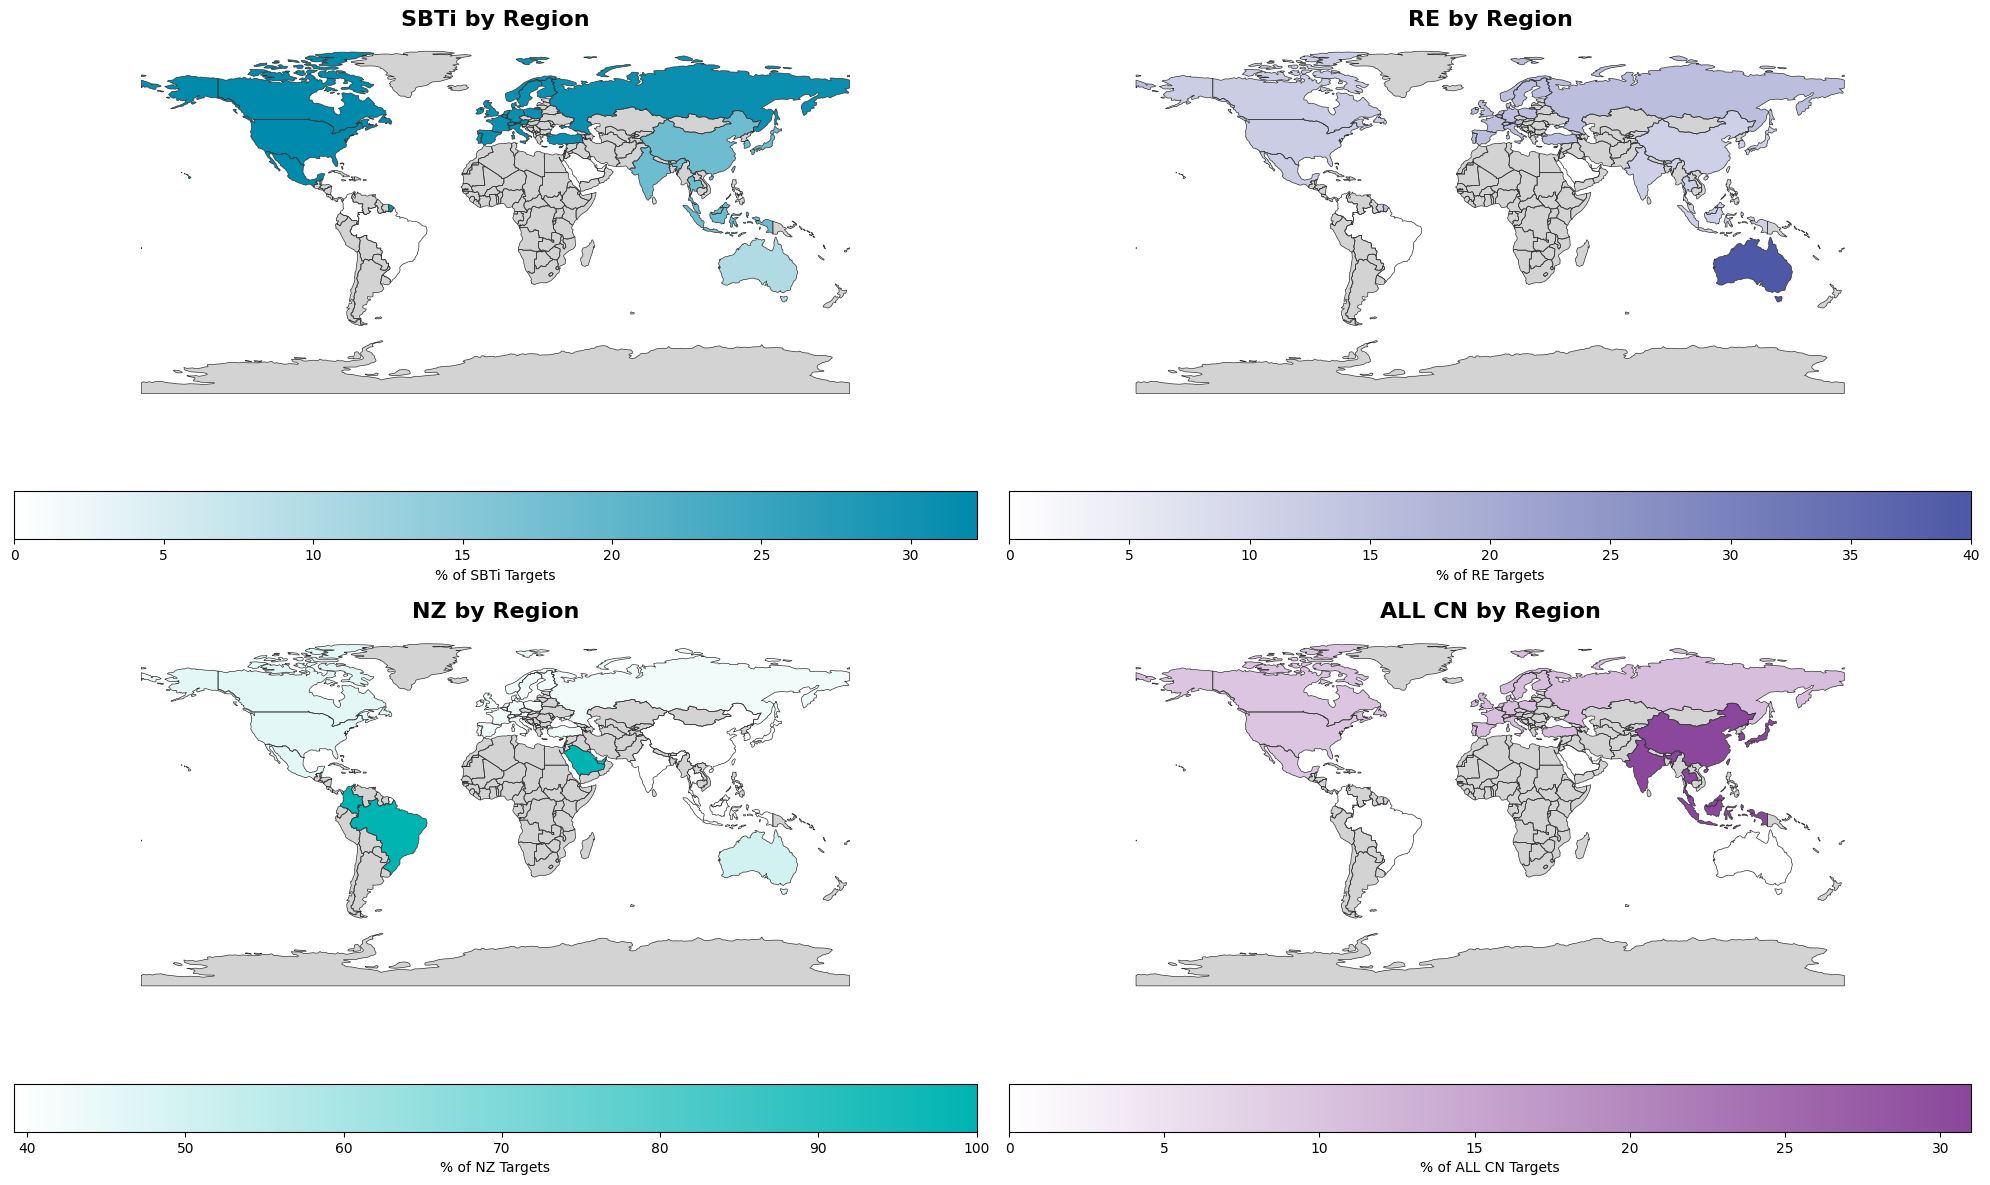

In [11]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- Load data ---
df = pd.read_excel(
    r'C:\Users\AniyaBagheri\GF500_research_perliminary_data_analysis\FG500_DataCollection_FY26_v4.cleaned.xlsm.xlsx',
    sheet_name='FG500_DataCollection_FY26',
    skiprows=2
)

df['Country'] = df['Country'].replace({'Britain': 'U.K.'})
df.columns = df.columns.str.strip()

# --- Region mapping ---
region_map = {
    'U.S.': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    'China': 'Asia', 'Japan': 'Asia', 'India': 'Asia', 'South Korea': 'Asia', 'Taiwan': 'Asia',
    'Thailand': 'Asia', 'Singapore': 'Asia', 'Malaysia': 'Asia', 'Indonesia': 'Asia',
    'Germany': 'Europe', 'U.K.': 'Europe', 'France': 'Europe', 'Italy': 'Europe', 
    'Russia': 'Europe', 'Spain': 'Europe', 'Netherlands': 'Europe', 'Switzerland': 'Europe',
    'Turkey': 'Europe', 'Poland': 'Europe', 'Belgium': 'Europe', 'Sweden': 'Europe',
    'Ireland': 'Europe', 'Austria': 'Europe', 'Norway': 'Europe', 'Denmark': 'Europe',
    'Finland': 'Europe', 'Portugal': 'Europe', 'Luxembourg': 'Europe',
    'Saudi Arabia': 'Middle East', 'UAE': 'Middle East', 'Qatar': 'Middle East',
    'Brazil': 'Latin America', 'Colombia': 'Latin America',
    'Australia': 'Oceania'
}

df['Region'] = df['Country'].map(region_map)

required_columns = ['ALL CN', 'All SBTi ST', 'All NZ', 'All RE']

# --- Aggregate data by region ---
region_data = df.groupby('Region')[required_columns].sum().reset_index()
region_data['Total'] = region_data[required_columns].sum(axis=1)
for col in required_columns:
    region_data[f'{col}_pct'] = (region_data[col] / region_data['Total'] * 100).round(1)

# --- Load world shapefile ---
world = gpd.read_file(r"C:\Users\AniyaBagheri\GF500_research_perliminary_data_analysis\ne_110m_admin_0_countries.shp")

# --- Create mapping from shapefile country names to your regions ---
shapefile_to_region = {
    'United States of America': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    'China': 'Asia', 'Japan': 'Asia', 'India': 'Asia', 'South Korea': 'Asia', 'Taiwan': 'Asia',
    'Thailand': 'Asia', 'Singapore': 'Asia', 'Malaysia': 'Asia', 'Indonesia': 'Asia',
    'Germany': 'Europe', 'United Kingdom': 'Europe', 'France': 'Europe', 'Italy': 'Europe', 
    'Russia': 'Europe', 'Spain': 'Europe', 'Netherlands': 'Europe', 'Switzerland': 'Europe',
    'Turkey': 'Europe', 'Poland': 'Europe', 'Belgium': 'Europe', 'Sweden': 'Europe',
    'Ireland': 'Europe', 'Austria': 'Europe', 'Norway': 'Europe', 'Denmark': 'Europe',
    'Finland': 'Europe', 'Portugal': 'Europe', 'Luxembourg': 'Europe',
    'Saudi Arabia': 'Middle East', 'United Arab Emirates': 'Middle East', 'Qatar': 'Middle East',
    'Brazil': 'Latin America', 'Colombia': 'Latin America',
    'Australia': 'Oceania'
}

world['Region'] = world['NAME'].map(shapefile_to_region)

# --- Brand colors ---
brand_colors = {
    'All SBTi ST': '#008AAC',
    'All RE': '#4D58A6', 
    'All NZ': '#00B4B2',
    'ALL CN': '#8B479B'
}

# --- Create custom colormaps ---
def create_brand_cmap(hex_color):
    """Create a colormap from white to brand color"""
    return LinearSegmentedColormap.from_list('brand', ['#FFFFFF', hex_color])

# --- Plotting setup ---
targets = ['All SBTi ST', 'All RE', 'All NZ', 'ALL CN']

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

for ax, target in zip(axes, targets):
    # Map region percentages to countries
    pct_map = region_data.set_index('Region')[f'{target}_pct'].to_dict()
    world['color_pct'] = world['Region'].map(pct_map)
    
    cmap = create_brand_cmap(brand_colors[target])
    
    world.boundary.plot(ax=ax, linewidth=0.5, color='#333333')
    world.plot(column='color_pct', ax=ax, cmap=cmap, legend=True, 
               missing_kwds={'color': 'lightgray'},
               legend_kwds={'label': f"% of {target.replace('All ', '').replace(' ST','')} Targets",
                            'orientation': "horizontal"})
    
    ax.set_title(f"{target.replace('All ', '').replace(' ST','')} by Region", fontsize=16, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig("regional_targets_map.png", dpi=300, bbox_inches='tight')
plt.show()

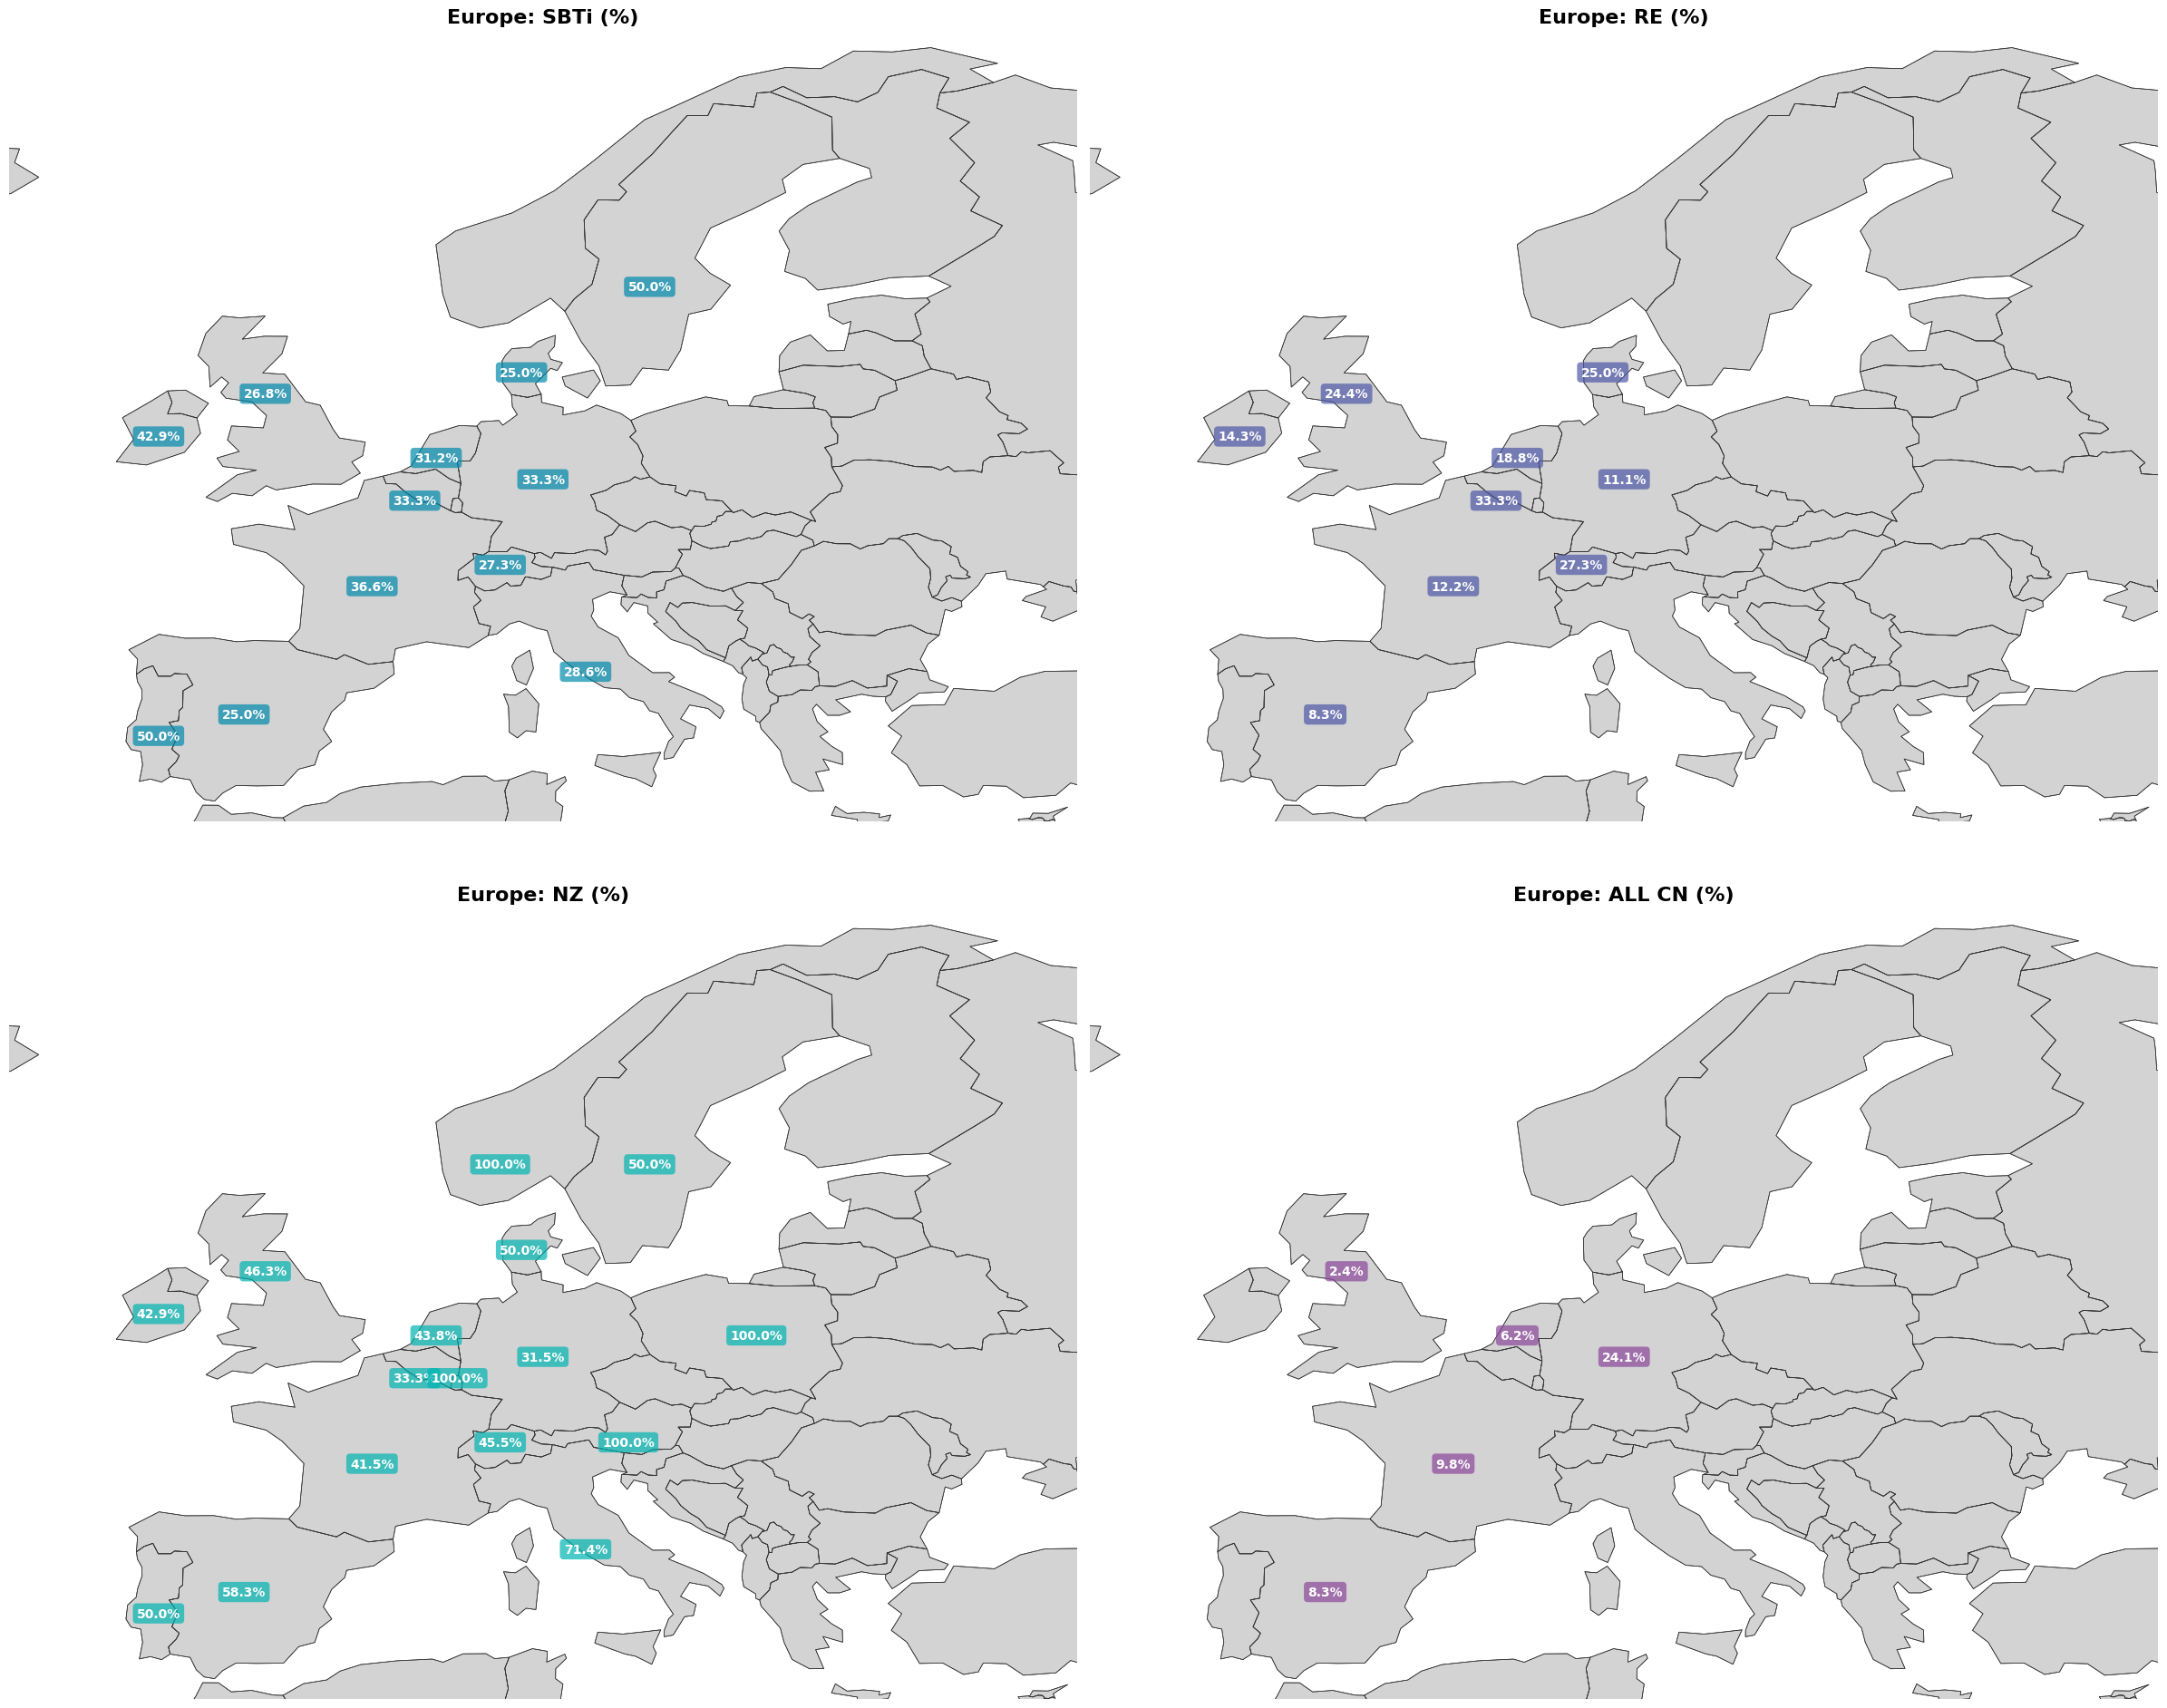

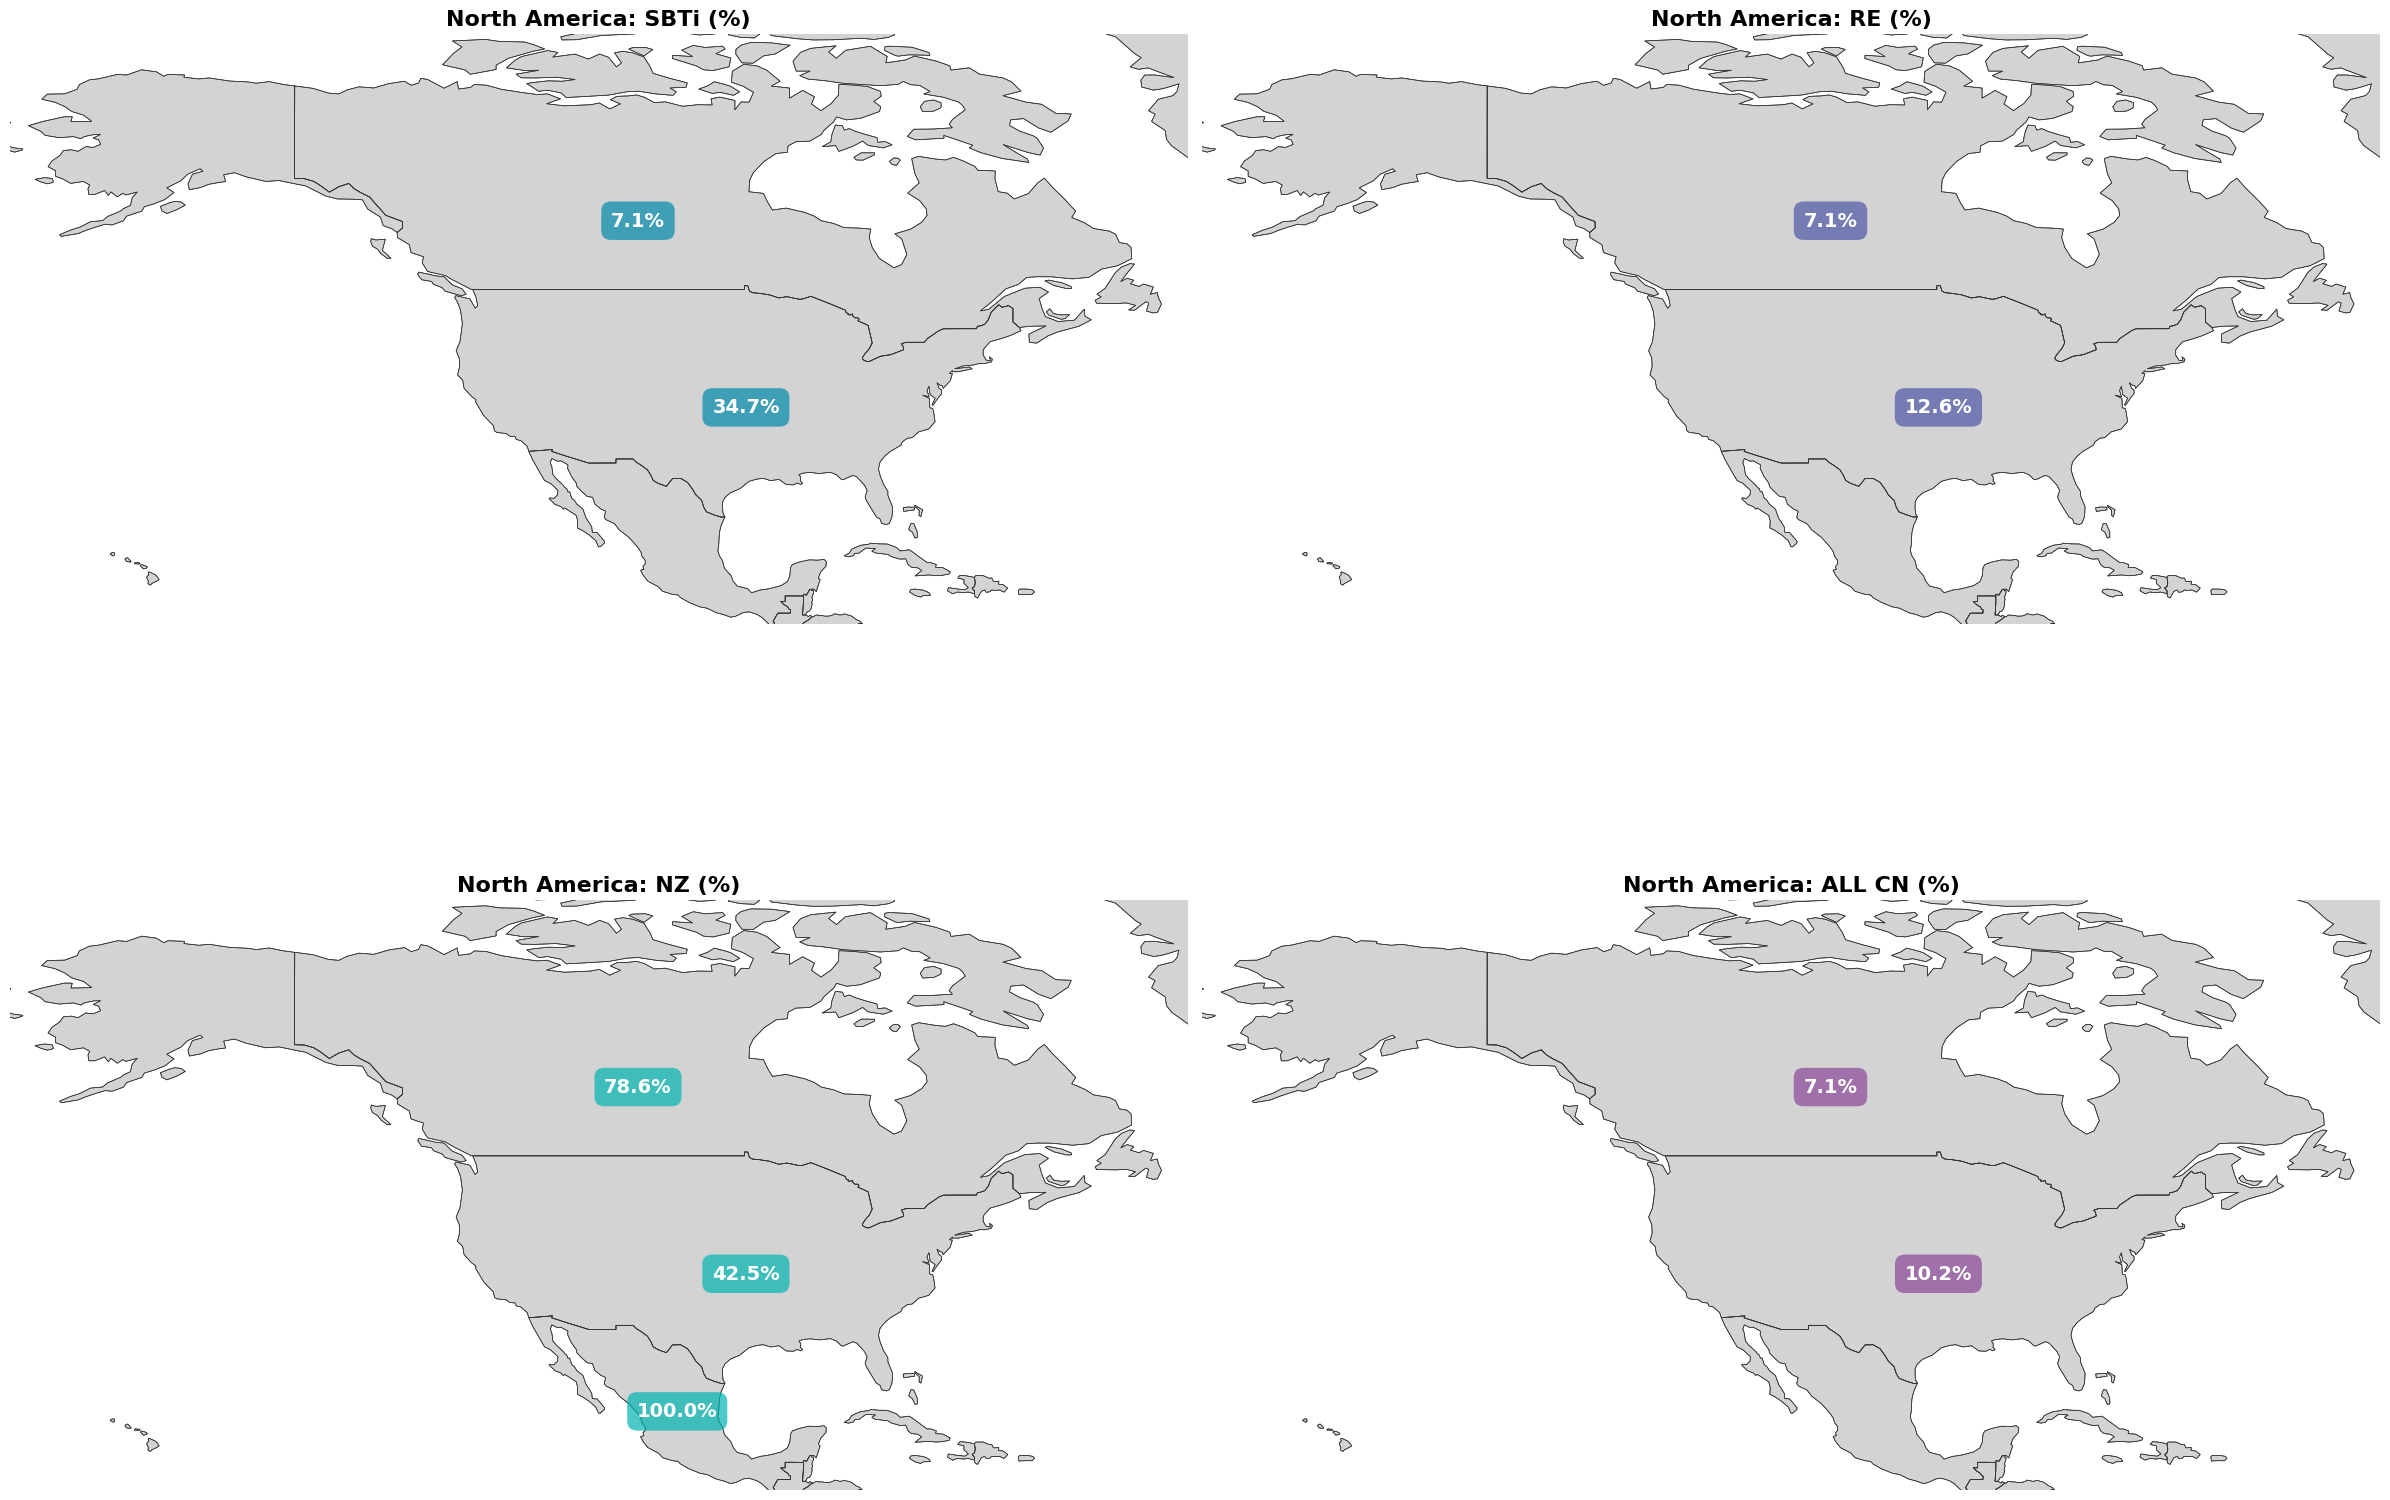

In [12]:
# --- ZOOMED MAPS: Europe and North America ---

# Country coordinates for labels
country_coords = {
    'United States of America': (-95, 37),
    'Canada': (-106, 56),
    'Mexico': (-102, 23),
    'Germany': (10, 51),
    'United Kingdom': (-3, 55),
    'France': (2, 46),
    'Italy': (12, 42),
    'Spain': (-4, 40),
    'Netherlands': (5, 52),
    'Switzerland': (8, 47),
    'Poland': (20, 52),
    'Belgium': (4, 50),
    'Sweden': (15, 60),
    'Ireland': (-8, 53),
    'Austria': (14, 47),
    'Norway': (8, 60),
    'Denmark': (9, 56),
    'Finland': (26, 64),
    'Portugal': (-8, 39),
    'Luxembourg': (6, 50)
}

# Get country-level data
country_data = df.groupby('Country')[required_columns].sum().reset_index()
country_data['Total'] = country_data[required_columns].sum(axis=1)
for col in required_columns:
    country_data[f'{col}_pct'] = (country_data[col] / country_data['Total'] * 100).round(1)

# Map your country names to shapefile names
your_country_to_shapefile = {
    'U.S.': 'United States of America',
    'U.K.': 'United Kingdom',
    'Canada': 'Canada',
    'Mexico': 'Mexico',
    'Germany': 'Germany',
    'France': 'France',
    'Italy': 'Italy',
    'Spain': 'Spain',
    'Netherlands': 'Netherlands',
    'Switzerland': 'Switzerland',
    'Poland': 'Poland',
    'Belgium': 'Belgium',
    'Sweden': 'Sweden',
    'Ireland': 'Ireland',
    'Austria': 'Austria',
    'Norway': 'Norway',
    'Denmark': 'Denmark',
    'Finland': 'Finland',
    'Portugal': 'Portugal',
    'Luxembourg': 'Luxembourg'
}

country_data['Shapefile_Name'] = country_data['Country'].map(your_country_to_shapefile)

# --- EUROPE MAP ---
fig, axes = plt.subplots(2, 2, figsize=(24, 20))
axes = axes.flatten()

europe_bounds = [-15, 35, 35, 72]  # [min_lon, max_lon, min_lat, max_lat]

for ax, target in zip(axes, targets):
    world.boundary.plot(ax=ax, linewidth=0.5, color='#333333')
    world.plot(ax=ax, color='lightgray', edgecolor='#333333', linewidth=0.5)
    
    ax.set_xlim(europe_bounds[0], europe_bounds[1])
    ax.set_ylim(europe_bounds[2], europe_bounds[3])
    
    # Add target percentages as text labels
    for _, row in country_data[country_data['Country'].isin(your_country_to_shapefile.keys())].iterrows():
        shapefile_name = row['Shapefile_Name']
        if shapefile_name in country_coords:
            lon, lat = country_coords[shapefile_name]
            if europe_bounds[0] <= lon <= europe_bounds[1] and europe_bounds[2] <= lat <= europe_bounds[3]:
                pct = row[f'{target}_pct']
                if pct > 0:
                    ax.text(lon, lat, f"{pct:.1f}%", 
                           fontsize=10, ha='center', va='center',
                           bbox=dict(boxstyle='round,pad=0.3', facecolor=brand_colors[target], alpha=0.7, edgecolor='none'),
                           color='white', fontweight='bold')
    
    ax.set_title(f"Europe: {target.replace('All ', '').replace(' ST','')} (%)", fontsize=16, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig("europe_targets_map.png", dpi=300, bbox_inches='tight')
plt.show()

# --- NORTH AMERICA MAP ---
fig, axes = plt.subplots(2, 2, figsize=(24, 20))
axes = axes.flatten()

na_bounds = [-170, -50, 15, 75]

for ax, target in zip(axes, targets):
    world.boundary.plot(ax=ax, linewidth=0.5, color='#333333')
    world.plot(ax=ax, color='lightgray', edgecolor='#333333', linewidth=0.5)
    
    ax.set_xlim(na_bounds[0], na_bounds[1])
    ax.set_ylim(na_bounds[2], na_bounds[3])
    
    for _, row in country_data[country_data['Country'].isin(['U.S.', 'Canada', 'Mexico'])].iterrows():
        shapefile_name = row['Shapefile_Name']
        if shapefile_name in country_coords:
            lon, lat = country_coords[shapefile_name]
            pct = row[f'{target}_pct']
            if pct > 0:
                ax.text(lon, lat, f"{pct:.1f}%", 
                       fontsize=14, ha='center', va='center',
                       bbox=dict(boxstyle='round,pad=0.5', facecolor=brand_colors[target], alpha=0.7, edgecolor='none'),
                       color='white', fontweight='bold')
    
    ax.set_title(f"North America: {target.replace('All ', '').replace(' ST','')} (%)", fontsize=16, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig("north_america_targets_map.png", dpi=300, bbox_inches='tight')
plt.show()

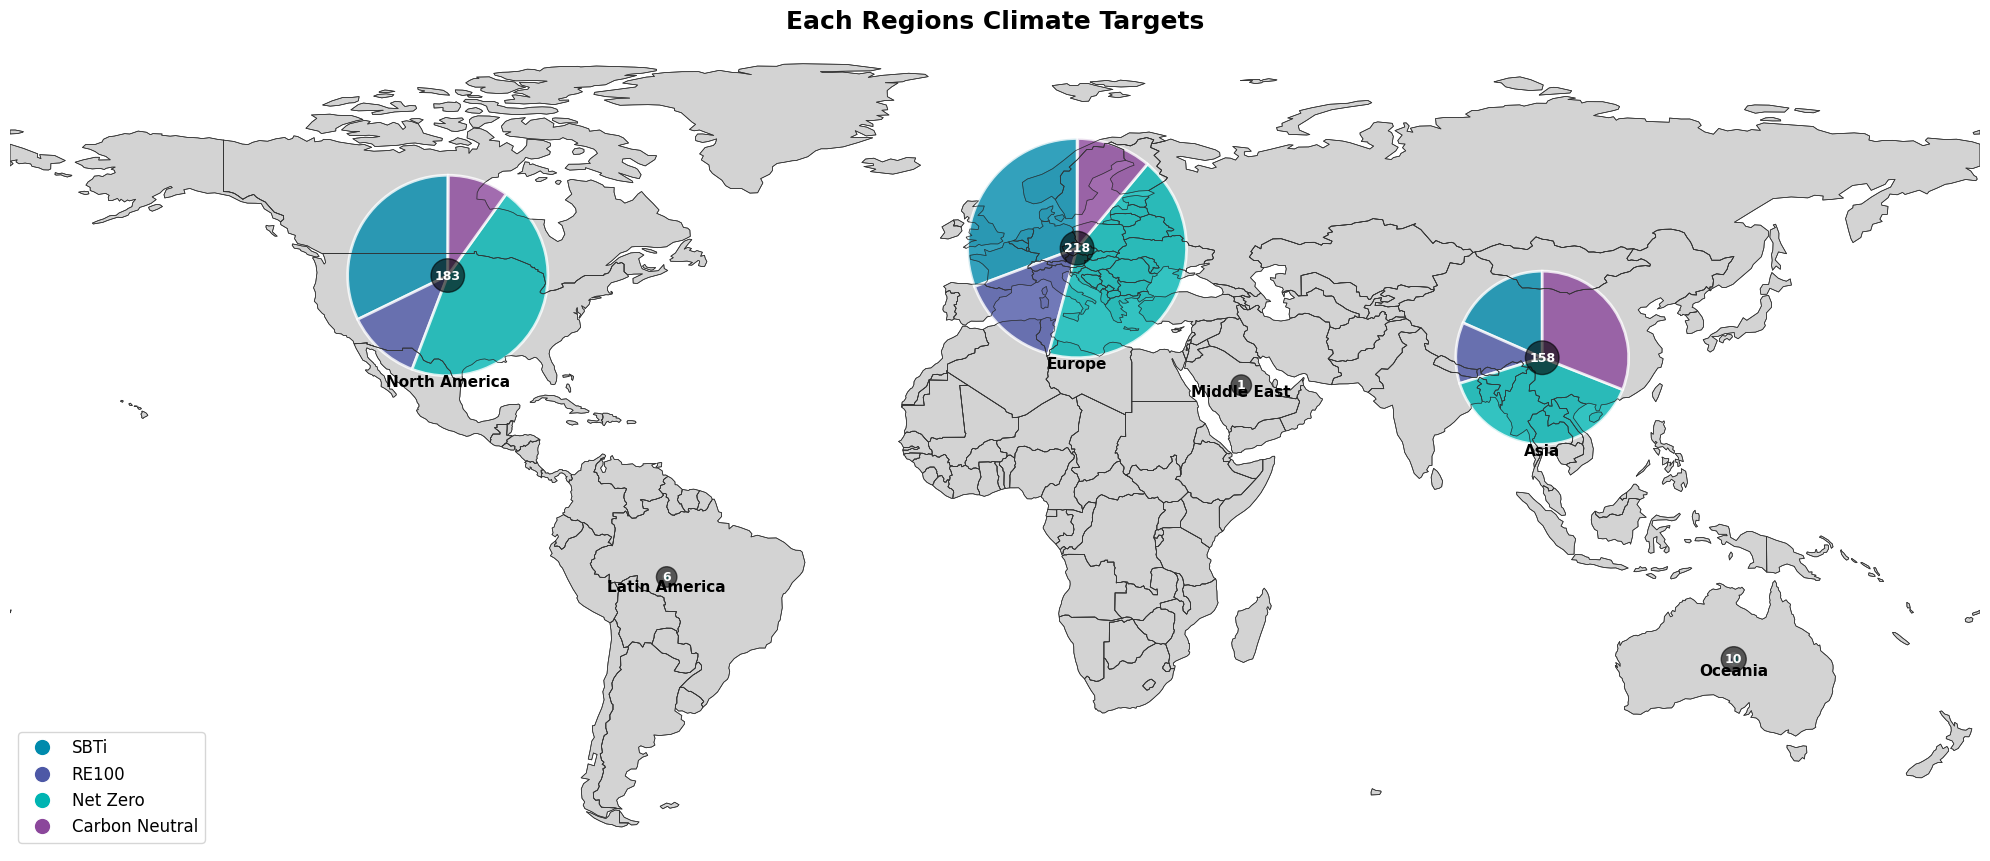

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import numpy as np

# --- Load data ---
df = pd.read_excel(
    r'C:\Users\AniyaBagheri\GF500_research_perliminary_data_analysis\FG500_DataCollection_FY26_v4.cleaned.xlsm.xlsx',
    sheet_name='FG500_DataCollection_FY26',
    skiprows=2
)

df['Country'] = df['Country'].replace({'Britain': 'U.K.'})
df.columns = df.columns.str.strip()

# --- Region mapping ---
region_map = {
    'U.S.': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    'China': 'Asia', 'Japan': 'Asia', 'India': 'Asia', 'South Korea': 'Asia', 'Taiwan': 'Asia',
    'Thailand': 'Asia', 'Singapore': 'Asia', 'Malaysia': 'Asia', 'Indonesia': 'Asia',
    'Germany': 'Europe', 'U.K.': 'Europe', 'France': 'Europe', 'Italy': 'Europe', 
    'Russia': 'Europe', 'Spain': 'Europe', 'Netherlands': 'Europe', 'Switzerland': 'Europe',
    'Turkey': 'Europe', 'Poland': 'Europe', 'Belgium': 'Belgium', 'Sweden': 'Europe',
    'Ireland': 'Europe', 'Austria': 'Europe', 'Norway': 'Europe', 'Denmark': 'Europe',
    'Finland': 'Europe', 'Portugal': 'Europe', 'Luxembourg': 'Europe',
    'Saudi Arabia': 'Middle East', 'UAE': 'Middle East', 'Qatar': 'Middle East',
    'Brazil': 'Latin America', 'Colombia': 'Latin America',
    'Australia': 'Oceania'
}

df['Region'] = df['Country'].map(region_map)

required_columns = ['ALL CN', 'All SBTi ST', 'All NZ', 'All RE']

# --- Aggregate data by region ---
region_data = df.groupby('Region')[required_columns].sum().reset_index()
region_data['Total'] = region_data[required_columns].sum(axis=1)
for col in required_columns:
    region_data[f'{col}_pct'] = (region_data[col] / region_data['Total'] * 100).round(1)

# --- Load world shapefile ---
world = gpd.read_file(r"C:\Users\AniyaBagheri\GF500_research_perliminary_data_analysis\ne_110m_admin_0_countries.shp")

# --- Region coordinates for pie charts ---
region_coords = {
    'North America': (-100, 45),
    'Europe': (15, 50),
    'Asia': (100, 30),
    'Middle East': (45, 25),
    'Latin America': (-60, -10),
    'Oceania': (135, -25)
}

# --- Brand colors ---
brand_colors = {
    'All SBTi ST': '#008AAC',
    'All RE': '#4D58A6', 
    'All NZ': '#00B4B2',
    'ALL CN': '#8B479B'
}

# --- Create figure ---
fig, ax = plt.subplots(figsize=(20, 12))

world.boundary.plot(ax=ax, linewidth=0.5, color='#333333')
world.plot(ax=ax, color='lightgray', edgecolor='#333333', linewidth=0.5)

# --- Draw pie charts on map ---
for _, row in region_data.iterrows():
    region = row['Region']
    if region in region_coords:
        lon, lat = region_coords[region]
        
        # Get percentages
        percentages = [row['All SBTi ST_pct'], row['All RE_pct'], row['All NZ_pct'], row['ALL CN_pct']]
        colors = ['#008AAC', '#4D58A6', '#00B4B2', '#8B479B']
        labels = ['SBTi', 'RE100', 'NZ', 'CN']
        
        # Draw pie chart at region location
        # Size based on total targets
        size = min(row['Total'] / 10, )  # Scale pie size
        
        start_angle = 90
        for pct, color, label in zip(percentages, colors, labels):
            if pct > 0:
                angle = pct * 3.6  # Convert % to degrees
                wedge = Wedge((lon, lat), size, start_angle, start_angle + angle, 
                             facecolor=color, edgecolor='white', linewidth=2, alpha=0.8,
                             transform=ax.transData)
                ax.add_patch(wedge)
                start_angle += angle
        
        # Add region label below pie
        ax.text(lon, lat - size - 2, region, fontsize=11, ha='center', fontweight='bold')
        
        # Add total count
        ax.text(lon, lat, int(row['Total']), fontsize=9, ha='center', va='center', 
               fontweight='bold', color='white',
               bbox=dict(boxstyle='circle', facecolor='black', alpha=0.6))

# --- Add legend ---
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=color, markersize=12, label=label)
                   for color, label in zip(['#008AAC', '#4D58A6', '#00B4B2', '#8B479B'],
                                          ['SBTi', 'RE100', 'Net Zero', 'Carbon Neutral'])]
ax.legend(handles=legend_elements, loc='lower left', fontsize=12, frameon=True)

ax.set_xlim(-180, 180)
ax.set_ylim(-60, 85)
ax.axis('off')
ax.set_title('Each Regions Climate Targets', fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig("regional_targets_pie_map.png", dpi=300, bbox_inches='tight')
plt.show()

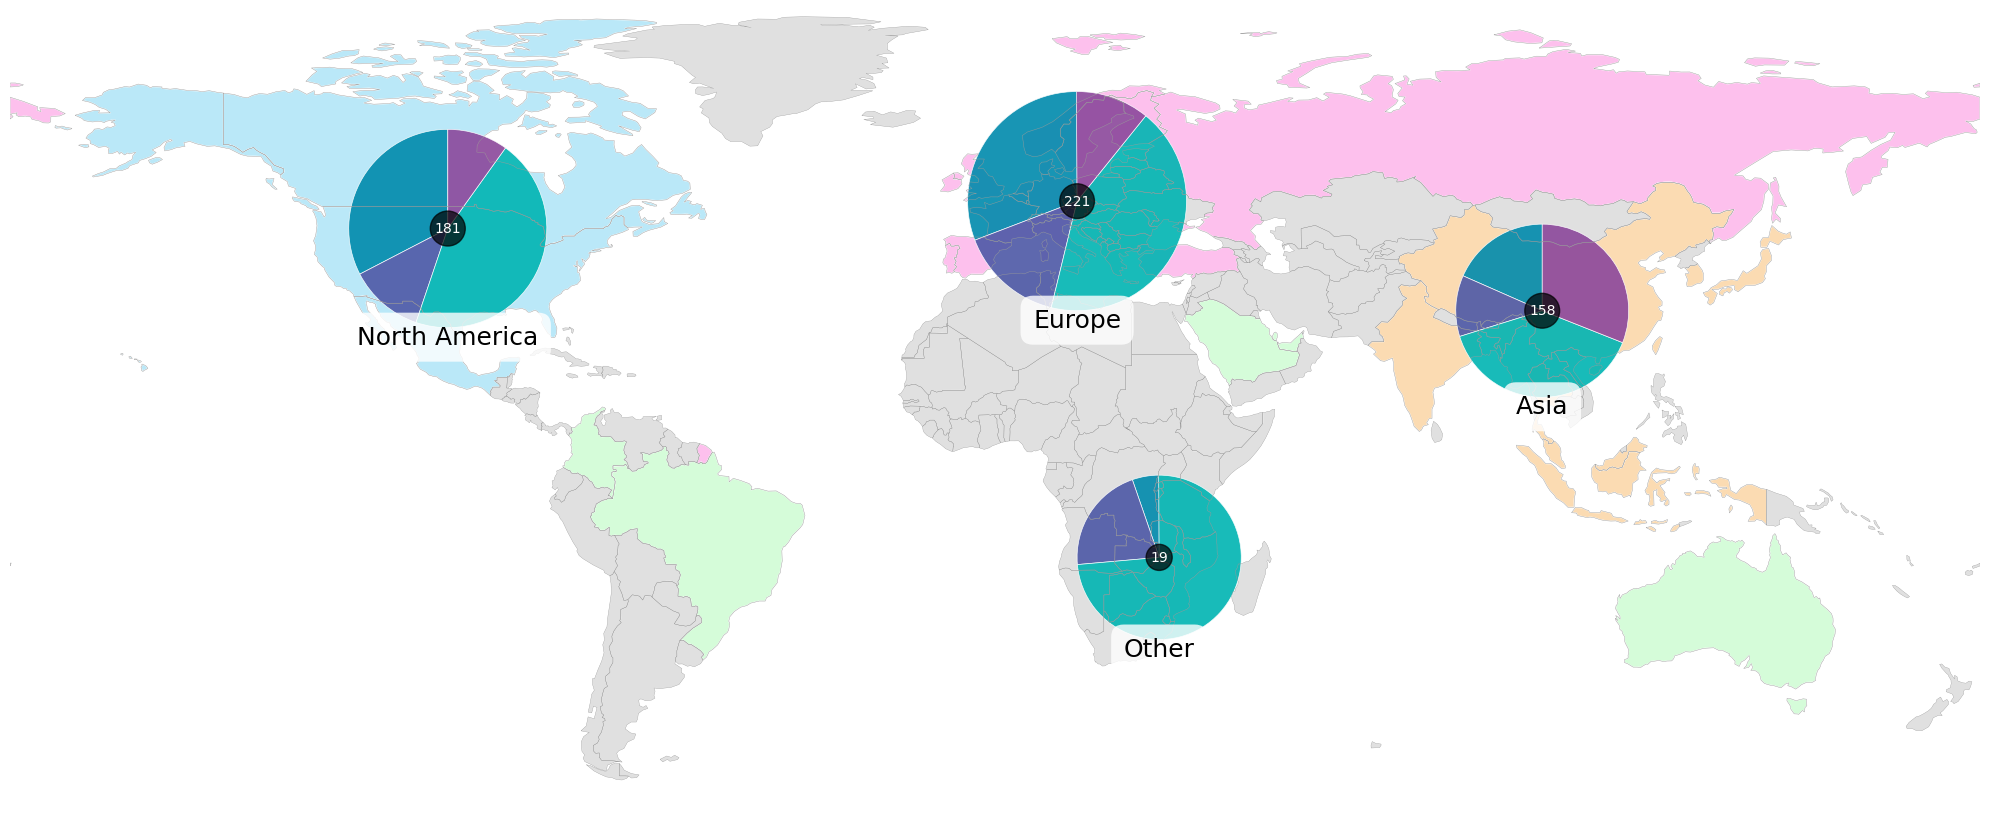

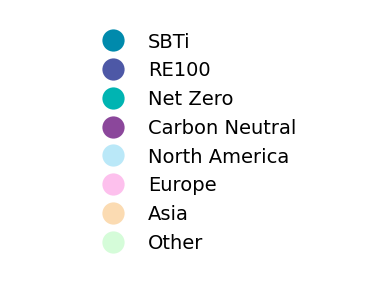

In [31]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import numpy as np

# --- Load data ---
df = pd.read_excel(
    r'C:\Users\AniyaBagheri\GF500_research_perliminary_data_analysis\FG500_DataCollection_FY26_v4.cleaned.xlsm.xlsx',
    sheet_name='FG500_DataCollection_FY26',
    skiprows=2
)

df['Country'] = df['Country'].replace({'Britain': 'U.K.'})
df.columns = df.columns.str.strip()

# --- Region mapping ---
region_map = {
    'U.S.': 'North America', 'Canada': 'North America', 'Mexico': 'Other',
    'China': 'Asia', 'Japan': 'Asia', 'India': 'Asia', 'South Korea': 'Asia', 'Taiwan': 'Asia',
    'Thailand': 'Asia', 'Singapore': 'Asia', 'Malaysia': 'Asia', 'Indonesia': 'Asia',
    'Germany': 'Europe', 'U.K.': 'Europe', 'France': 'Europe', 'Italy': 'Europe', 
    'Russia': 'Europe', 'Spain': 'Europe', 'Netherlands': 'Europe', 'Switzerland': 'Europe',
    'Turkey': 'Europe', 'Poland': 'Europe', 'Belgium': 'Europe', 'Sweden': 'Europe',
    'Ireland': 'Europe', 'Austria': 'Europe', 'Norway': 'Europe', 'Denmark': 'Europe',
    'Finland': 'Europe', 'Portugal': 'Europe', 'Luxembourg': 'Europe',
    'Saudi Arabia': 'Other', 'UAE': 'Other', 'Qatar': 'Other',
    'Brazil': 'Other', 'Colombia': 'Other',
    'Australia': 'Other'
}

df['Region'] = df['Country'].map(region_map)

required_columns = ['ALL CN', 'All SBTi ST', 'All NZ', 'All RE']

# --- Aggregate data by region ---
region_data = df.groupby('Region')[required_columns].sum().reset_index()
region_data['Total'] = region_data[required_columns].sum(axis=1)
for col in required_columns:
    region_data[f'{col}_pct'] = (region_data[col] / region_data['Total'] * 100).round(1)

# --- Load world shapefile ---
world = gpd.read_file(r"C:\Users\AniyaBagheri\GF500_research_perliminary_data_analysis\ne_110m_admin_0_countries.shp")

# --- Map shapefile countries to regions ---
shapefile_to_region = {
    'United States of America': 'North America', 'Canada': 'North America', 'Mexico': 'North America',
    'China': 'Asia', 'Japan': 'Asia', 'India': 'Asia', 'South Korea': 'Asia', 'Taiwan': 'Asia',
    'Thailand': 'Asia', 'Singapore': 'Asia', 'Malaysia': 'Asia', 'Indonesia': 'Asia',
    'Germany': 'Europe', 'United Kingdom': 'Europe', 'France': 'Europe', 'Italy': 'Europe', 
    'Russia': 'Europe', 'Spain': 'Europe', 'Netherlands': 'Europe', 'Switzerland': 'Europe',
    'Turkey': 'Europe', 'Poland': 'Europe', 'Belgium': 'Europe', 'Sweden': 'Europe',
    'Ireland': 'Europe', 'Austria': 'Europe', 'Norway': 'Europe', 'Denmark': 'Europe',
    'Finland': 'Europe', 'Portugal': 'Europe', 'Luxembourg': 'Europe',
    'Saudi Arabia': 'Other', 'United Arab Emirates': 'Other', 'Qatar': 'Other',
    'Brazil': 'Other', 'Colombia': 'Other',
    'Australia': 'Other'
}

world['Region'] = world['NAME'].map(shapefile_to_region)

# --- Region colors (light pastels so pie charts stand out) ---
region_colors = {
    'North America': "#BAE8F8",
    'Europe': "#FDC0ED",
    'Asia': "#FBDBB2",
    'Other': "#D5FCD9"
}

# --- Region coordinates for pie charts ---
region_coords = {
    'North America': (-100, 45),
    'Europe': (15, 50),
    'Asia': (100, 30),
    'Other': (30, -15)
}

# --- Brand colors ---
brand_colors = {
    'All SBTi ST': '#008AAC',
    'All RE': '#4D58A6', 
    'All NZ': '#00B4B2',
    'ALL CN': '#8B479B'
}

# --- Create MAP without legend ---
fig, ax = plt.subplots(figsize=(20, 12))
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

# --- Plot countries colored by region ---
for region, color in region_colors.items():
    world[world['Region'] == region].plot(ax=ax, color=color, edgecolor='white', linewidth=0.8)

world[world['Region'].isna()].plot(ax=ax, color='#E0E0E0', edgecolor='white', linewidth=0.5)
world.boundary.plot(ax=ax, linewidth=0.3, color='#999999')

# --- Draw pie charts on map ---
for _, row in region_data.iterrows():
    region = row['Region']
    if region in region_coords:
        lon, lat = region_coords[region]
        
        percentages = [row['All SBTi ST_pct'], row['All RE_pct'], row['All NZ_pct'], row['ALL CN_pct']]
        colors = ['#008AAC', '#4D58A6', '#00B4B2', '#8B479B']
        
        size = max(min(row['Total'] / 10, 20),15)
        
        start_angle = 90
        for pct, color in zip(percentages, colors):
            if pct > 0:
                angle = pct * 3.6
                wedge = Wedge((lon, lat), size, start_angle, start_angle + angle, 
                             facecolor=color, edgecolor='white', linewidth=0.5, alpha=0.9,
                             transform=ax.transData)
                ax.add_patch(wedge)
                start_angle += angle
        
        ax.text(lon, lat - size - 3, region, fontsize=18, ha='center', fontweight='light',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='none'))
        
        ax.text(lon, lat, int(row['Total']), fontsize=10, ha='center', va='center', 
               fontweight='light', color='white',
               bbox=dict(boxstyle='circle', facecolor='black', alpha=0.7))

ax.set_xlim(-180, 180)
ax.set_ylim(-60, 85)
ax.axis('off')

plt.tight_layout()
plt.savefig("regional_targets_pie_map.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# --- Create SEPARATE LEGEND as transparent PNG ---
fig_legend = plt.figure(figsize=(4, 3))
fig_legend.patch.set_alpha(0)

legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=color, markersize=16, label=label, markeredgewidth=0)
                   for color, label in zip(['#008AAC', '#4D58A6', '#00B4B2', '#8B479B',  '#BAE8F8', '#FDC0ED', '#FBDBB2', '#D5FCD9'],
                                          ['SBTi', 'RE100', 'Net Zero', 'Carbon Neutral','North America', 'Europe','Asia', 'Other'])]

legend = plt.legend(handles=legend_elements, loc='center', fontsize=14, frameon=False)

# Make text white with black outline for visibility
for text in legend.get_texts():
    text.set_color('black')
    text.set_fontweight('light')

plt.axis('off')
plt.tight_layout()
plt.savefig("legend.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
	SBTi NT 	RE100	CN	NZ
Asia	29	18	49	62
Europe	68	34	24	95
North America	59	22	18	82
other	1	4	0	14

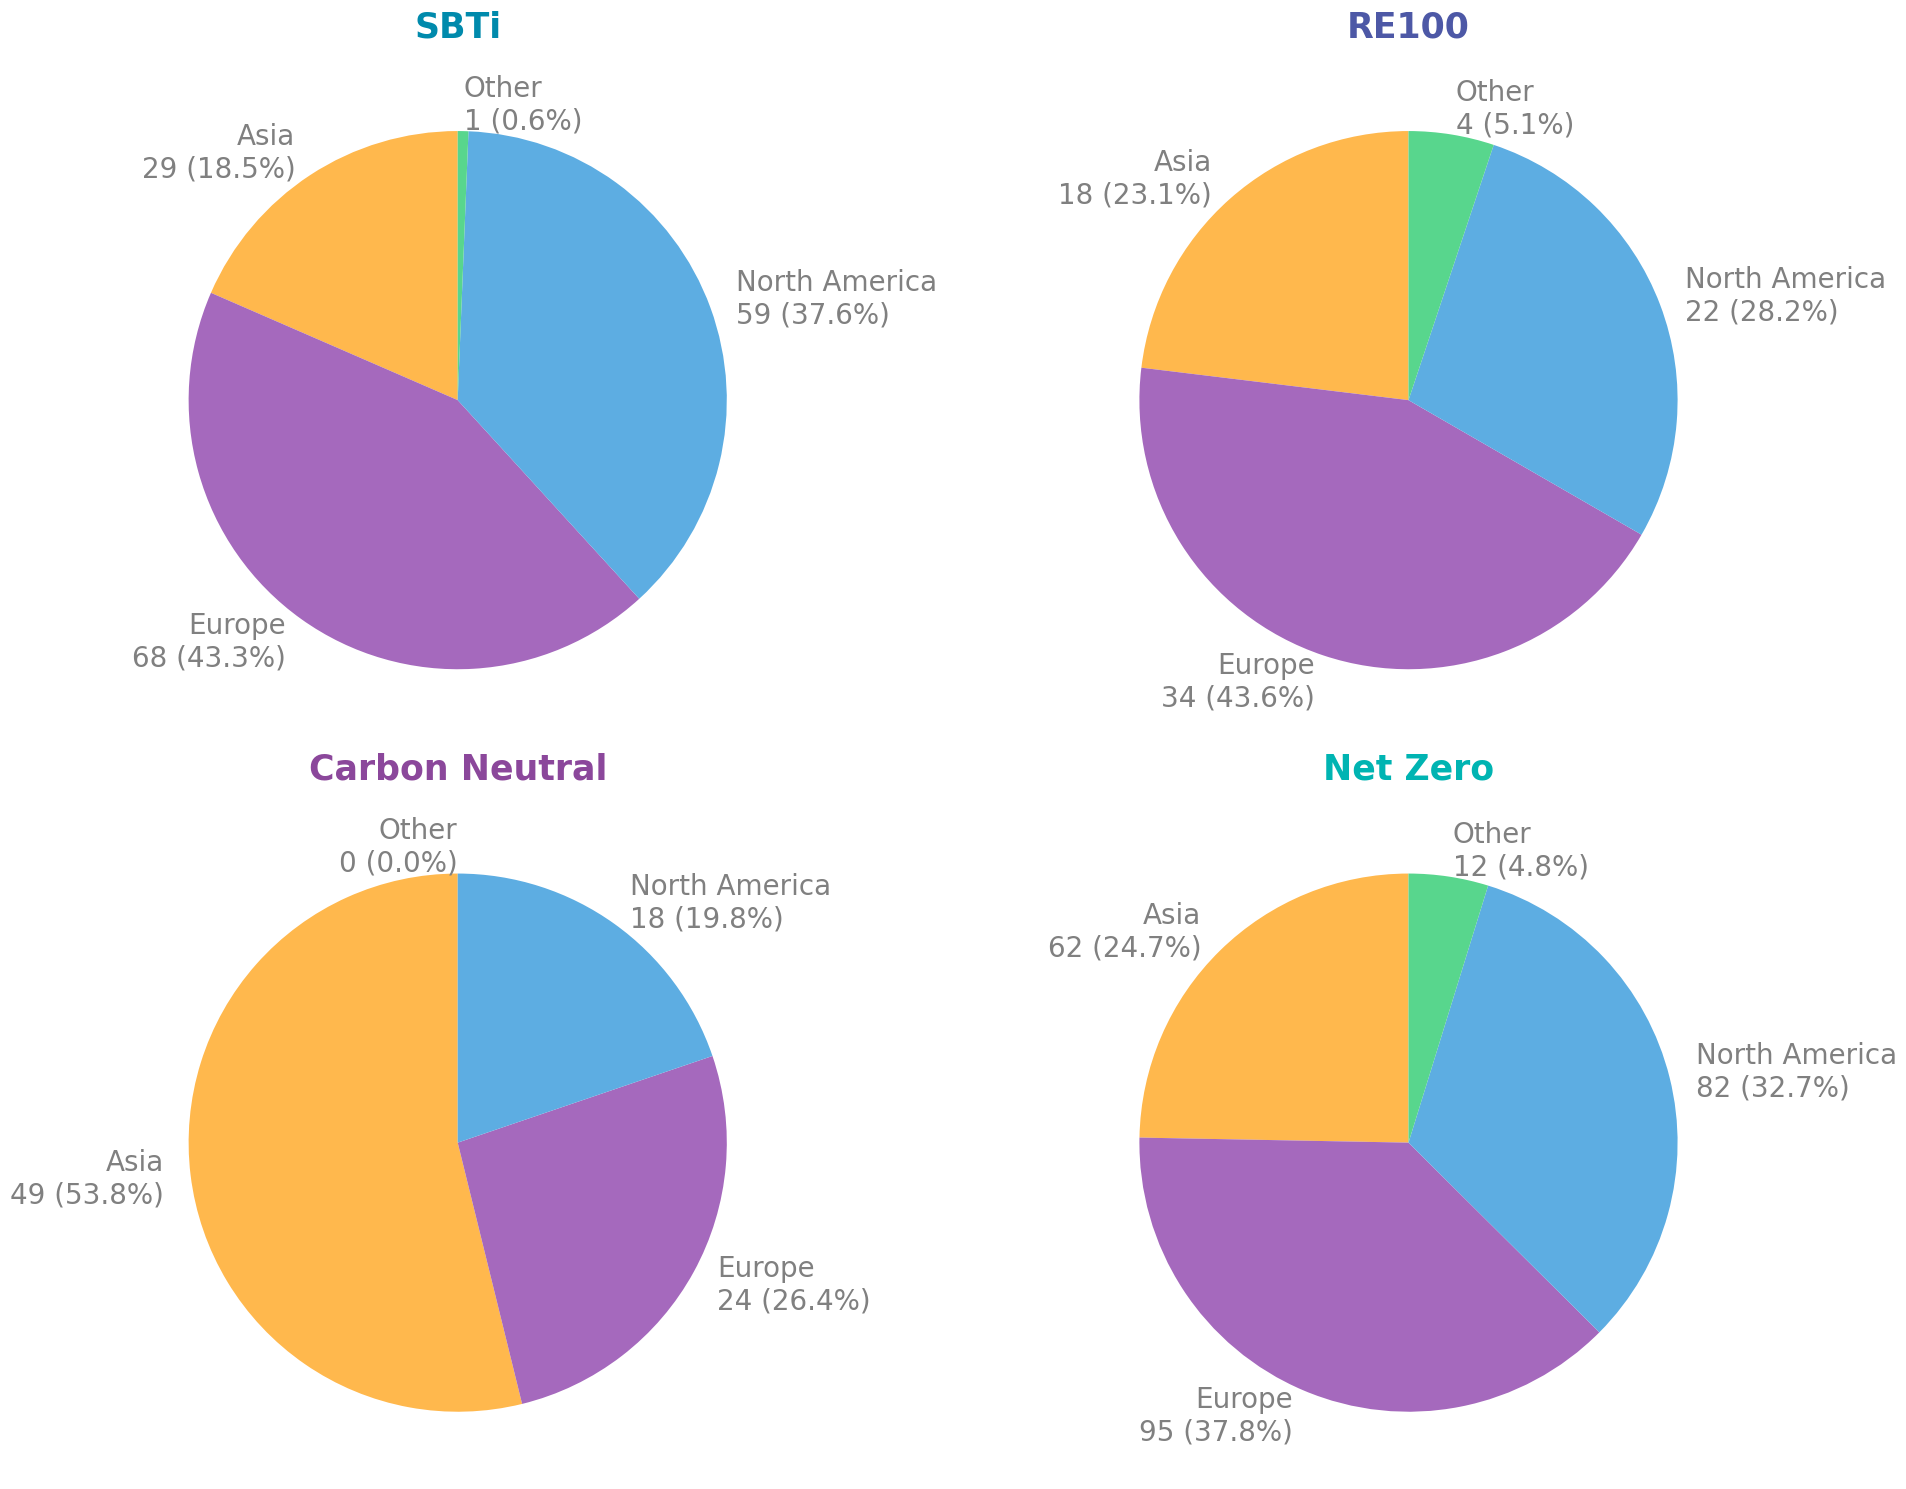

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Data ---
data = {
    'Region': ['Asia', 'Europe', 'North America', 'Other'],
    'SBTi': [29, 68, 59, 1],
    'RE100': [18, 34, 22, 4],
    'CN': [49, 24, 18, 0],
    'NZ': [62, 95, 82, 12]
}

df = pd.DataFrame(data)

# Calculate percentages for each target
for target in ['SBTi', 'RE100', 'CN', 'NZ']:
    total = df[target].sum()
    df[f'{target}_pct'] = (df[target] / total * 100).round(1)

# --- Brand colors ---
brand_colors = {
    'SBTi': '#008AAC',
    'RE100': '#4D58A6',
    'CN': '#8B479B',
    'NZ': '#00B4B2'
}

# Region colors for pie slices
region_colors = {
    'Asia': '#FFB84D',
    'Europe': '#A569BD',
    'North America': '#5DADE2',
    'Other': '#58D68D'
}

# --- Create 4 pie charts ---
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.patch.set_alpha(0)
axes = axes.flatten()

targets = ['SBTi', 'RE100', 'CN', 'NZ']
target_labels = {
    'SBTi': 'SBTi',
    'RE100': 'RE100',
    'CN': 'Carbon Neutral',
    'NZ': 'Net Zero'
}

for ax, target in zip(axes, targets):
    ax.patch.set_alpha(0)
    
    # Get data for this target
    sizes = df[target].values
    labels = [f"{region}\n{val} ({pct}%)" 
              for region, val, pct in zip(df['Region'], df[target], df[f'{target}_pct'])]
    colors = [region_colors[region] for region in df['Region']]
    
    # Create pie chart
    wedges, texts, autotexts = ax.pie(
        sizes, 
        labels=labels,
        colors=colors,
        autopct='',
        startangle=90,
        textprops={'fontsize': 20, 'fontweight': 'light'}
    )
    
    # Style
    for text in texts:
        text.set_color('grey')
    
    # Title with brand color
    ax.set_title(target_labels[target], 
                fontsize=25, 
                fontweight='bold', 
                color=brand_colors[target],
                pad=20)

plt.tight_layout()
plt.savefig("targets_by_region_pies.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

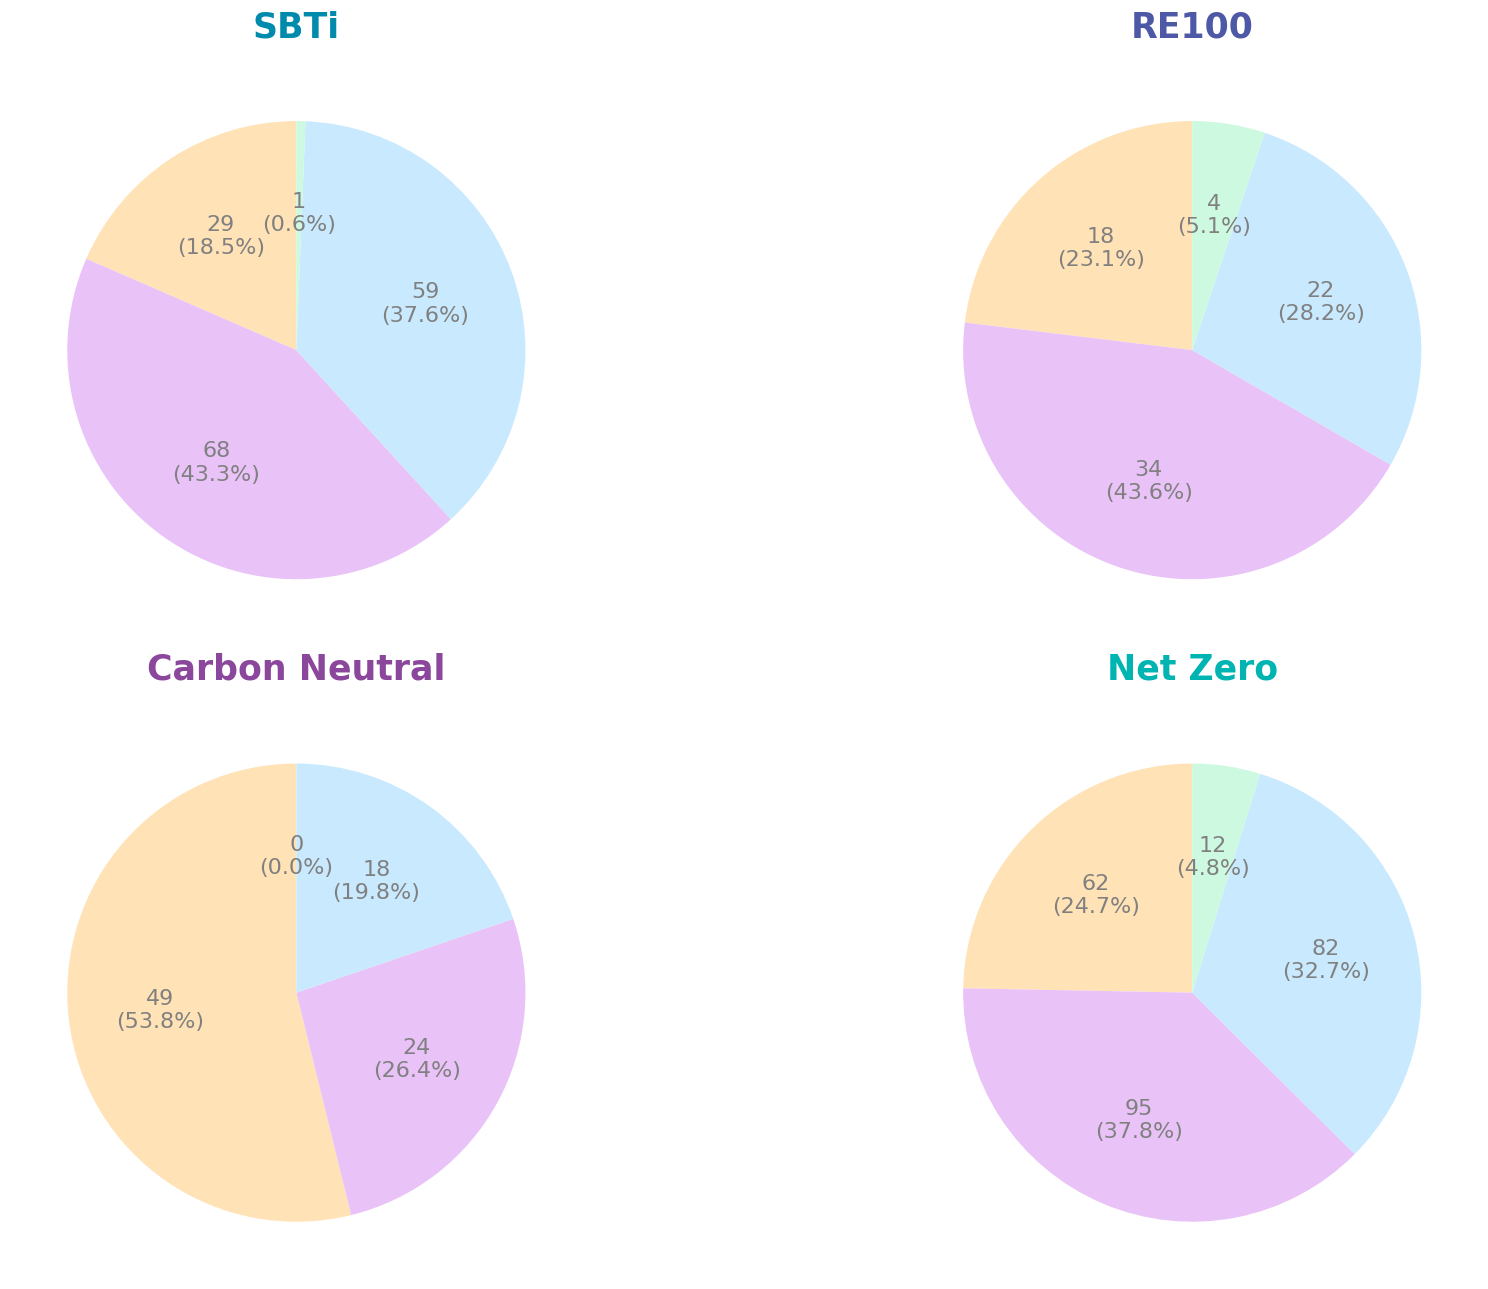

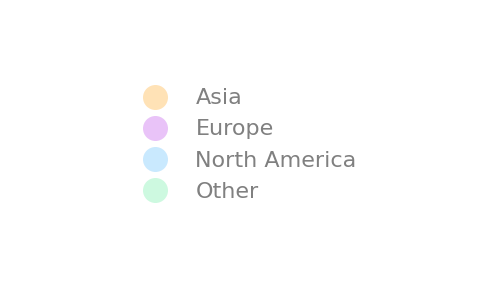

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Data ---
data = {
    'Region': ['Asia', 'Europe', 'North America', 'Other'],
    'SBTi': [29, 68, 59, 1],
    'RE100': [18, 34, 22, 4],
    'CN': [49, 24, 18, 0],
    'NZ': [62, 95, 82, 12]
}
df = pd.DataFrame(data)

# Calculate percentages for each target
for target in ['SBTi', 'RE100', 'CN', 'NZ']:
    total = df[target].sum()
    df[f'{target}_pct'] = (df[target] / total * 100).round(1)

# --- Brand colors ---
brand_colors = {
    'SBTi': '#008AAC',
    'RE100': '#4D58A6',
    'CN': '#8B479B',
    'NZ': '#00B4B2'
}

# Region colors for pie slices
region_colors = {
    'Asia': "#FFE2B6",
    'Europe': "#E9C3F8",
    'North America': "#C9E9FE",
    'Other': "#CDF9E0"
}

# --- Create 4 pie charts WITHOUT legend ---
fig, axes = plt.subplots(2, 2, figsize=(22, 13))
fig.patch.set_alpha(0)
plt.subplots_adjust(wspace=0.01, hspace=0.2) 
axes = axes.flatten()

targets = ['SBTi', 'RE100', 'CN', 'NZ']
target_labels = {
    'SBTi': 'SBTi',
    'RE100': 'RE100',
    'CN': 'Carbon Neutral',
    'NZ': 'Net Zero'
}

for ax, target in zip(axes, targets):
    ax.patch.set_alpha(0)
    
    # Get data for this target
    sizes = df[target].values
    colors = [region_colors[region] for region in df['Region']]
    
    # Custom autopct function to show count and percentage
    def make_autopct(values):
        def my_autopct(pct):
            total = sum(values)
            val = int(round(pct*total/100.0))
            return f'{val}\n({pct:.1f}%)'
        return my_autopct
    
    # Create pie chart with labels inside
    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=None,  # No labels outside
        colors=colors,
        autopct=make_autopct(sizes),
        startangle=90,
        textprops={'fontsize': 16, 'fontweight': 'light', 'color': 'grey'}
    )
    
    # Title with brand color
    ax.set_title(target_labels[target], 
                fontsize=25, 
                fontweight='bold', 
                color=brand_colors[target],
                pad=20)

plt.tight_layout()
plt.savefig("targets_by_region_pies.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# --- Create SEPARATE LEGEND ---
fig_legend = plt.figure(figsize=(5, 3))
fig_legend.patch.set_alpha(0)

legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=color, markersize=18, label=region, markeredgewidth=0)
                   for region, color in region_colors.items()]

legend = plt.legend(handles=legend_elements, loc='center', fontsize=16, frameon=False)

for text in legend.get_texts():
    text.set_color('grey')
    text.set_fontweight('light')

plt.axis('off')
plt.tight_layout()
plt.savefig("region_legend.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()